# Combined Step 8 + Step 9 (Colab Ready)

This notebook combines:
- **Step 8**: Gymnasium multi-case environment
- **Step 9**: MaskablePPO training + evaluation

Run cells top-to-bottom in Colab.
- Preferred: place `output.zip` in your Google Drive and let Cell 3 load it automatically.
- Optional: place `output.zip` directly in the Colab working directory (`/content`).

In [25]:
%pip install -q gymnasium stable-baselines3 sb3-contrib pyarrow pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 11.4 MB/s eta 0:00:00


In [26]:
import json
import time
import zipfile
import shutil
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from collections import defaultdict
from typing import List

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import BaseCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.utils import get_action_masks

ROOT = Path('.')
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ZIP_PATH = ROOT / 'output.zip'

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

DRIVE_ZIP_PATH = Path('/content/drive/MyDrive/output.zip')

def _extract_output_zip(zip_path: Path):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = [n for n in zf.namelist() if n and not n.endswith('/')]
        has_output_prefix = any(n.startswith('output/') for n in names)
        if has_output_prefix:
            zf.extractall(ROOT)
        else:
            zf.extractall(OUTPUT_DIR)

if IN_COLAB:
    selected_zip = OUTPUT_ZIP_PATH if OUTPUT_ZIP_PATH.exists() else None

    if selected_zip is None:
        try:
            from google.colab import drive  # type: ignore
            drive.mount('/content/drive', force_remount=False)
            selected_zip = DRIVE_ZIP_PATH if DRIVE_ZIP_PATH.exists() else None
        except Exception as exc:
            print(f'Google Drive mount failed: {exc}')

    if selected_zip is None:
        raise FileNotFoundError(
            'Could not find output.zip. Place it either at /content/output.zip '
            'or in Google Drive (e.g., /content/drive/MyDrive/output.zip), then re-run this cell.'
        )

    if selected_zip.resolve() != OUTPUT_ZIP_PATH.resolve():
        shutil.copy2(selected_zip, OUTPUT_ZIP_PATH)
        print(f'Copied zip from Drive to runtime: {selected_zip} -> {OUTPUT_ZIP_PATH}')
    else:
        print(f'Using runtime zip: {OUTPUT_ZIP_PATH}')

    _extract_output_zip(OUTPUT_ZIP_PATH)
    print(f'Output dir: {OUTPUT_DIR.resolve()}')
else:
    print('Not in Colab: skipping zip extraction. Expecting local ./output artifacts.')

required = [
    'case_step_features.parquet',
    'graph_priors.json',
    'transition_stats.csv',
    'duration_stats.csv',
    'valid_action_space.csv',
    'sim_calibration.json',
    'resource_calibration.json',
    'reward_params_kpi_tuned.json',
]
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing required files in ./output: {missing}')
print('All required artifacts found.')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied zip from Drive to runtime: /content/drive/MyDrive/output.zip -> output.zip
Output dir: /content/bureaucratic-workflow-analyzer/output
All required artifacts found.


In [38]:
FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
GRAPH_PRIORS_PATH = OUTPUT_DIR / 'graph_priors.json'
TRANSITION_STATS_PATH = OUTPUT_DIR / 'transition_stats.csv'
DURATION_STATS_PATH = OUTPUT_DIR / 'duration_stats.csv'
ACTION_SPACE_PATH = OUTPUT_DIR / 'valid_action_space.csv'
CALIBRATION_PATH = OUTPUT_DIR / 'sim_calibration.json'
TUNED_REWARD_PATH = OUTPUT_DIR / 'reward_params_kpi_tuned.json'
RESOURCE_CALIBRATION_PATH = OUTPUT_DIR / 'resource_calibration.json'

features_df = pd.read_parquet(FEATURES_PARQUET)
with open(GRAPH_PRIORS_PATH) as f:
    graph_priors = json.load(f)
transitions_df = pd.read_csv(TRANSITION_STATS_PATH)
durations_df = pd.read_csv(DURATION_STATS_PATH)
actions_df = pd.read_csv(ACTION_SPACE_PATH)

ACTION_MAP = dict(zip(actions_df['action_id'], actions_df['action_name']))
ACTION_NAME_TO_IDX = {v: k for k, v in ACTION_MAP.items()}
NUM_ACTIONS = len(ACTION_MAP)

with open(CALIBRATION_PATH) as f:
    calibration = json.load(f)
with open(TUNED_REWARD_PATH) as f:
    reward_tuning = json.load(f)
reward_params = reward_tuning.get('tuned_params', {'alpha': 0.02, 'beta': 0.75, 'delta': 2.5, 'gamma': 12.0})
with open(RESOURCE_CALIBRATION_PATH) as f:
    resource_config = json.load(f)

unique_activities = sorted(features_df['activity'].dropna().unique())
ACTIVITY_ENCODER = {act: idx for idx, act in enumerate(unique_activities)}
ACTIVITY_DECODER = {idx: act for act, idx in ACTIVITY_ENCODER.items()}

def build_transition_lookup():
    lookup = defaultdict(dict)
    for _, row in transitions_df.iterrows():
        src = str(row['activity'])
        tgt = str(row['next_activity'])
        prob = float(row['transition_prob'])
        lookup[src][tgt] = prob
    return dict(lookup)

def build_duration_lookup():
    lookup = {}
    for _, row in durations_df.iterrows():
        act = str(row['activity'])
        try:
            m = int(row['municipality'])
        except (ValueError, TypeError):
            continue
        lookup[(act, m)] = float(row['duration_median_hours'])
    return lookup

transition_lookup = build_transition_lookup()
duration_lookup = build_duration_lookup()
print(f'Loaded artifacts. Activities={len(unique_activities)}, actions={NUM_ACTIONS}, transitions={len(transition_lookup)}')

Loaded artifacts. Activities=356, actions=15, transitions=355


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
@dataclass
class Case:
    case_id: str
    municipality: int
    arrival_time: float
    current_activity: str = 'START'
    prev_activity: str = 'START'
    time_at_current: float = 0.0
    total_time: float = 0.0
    predicted_trace_length: int = 20
    step_index: int = 0
    rework_count: int = 0
    branch_label: str = 'unknown'
    branch_confidence: float = 0.5
    is_completed: bool = False
    completed_time: float = -1.0
    priority: float = 0.0

    def progress(self) -> float:
        return self.step_index / max(self.predicted_trace_length, 1)

class BPICMultiCaseEnv(gym.Env):
    def __init__(self, municipality=1, seed=None, max_episode_hours=168, resource_config=None):
        super().__init__()
        self.municipality = municipality
        self.max_episode_hours = max_episode_hours
        self.arrival_rate = 2.0
        self.np_random = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

        if resource_config and isinstance(resource_config, dict):
            by_m = resource_config.get('by_municipality', {})
            m_cfg = by_m.get(str(municipality)) or by_m.get(municipality)
            if m_cfg:
                self.min_workers = int(m_cfg.get('min_workers', 5))
                self.initial_workers = int(m_cfg.get('initial_workers', 6))
                self.max_workers = int(m_cfg.get('max_workers', 9))
            else:
                self.min_workers, self.initial_workers, self.max_workers = 5, 6, 9
        else:
            self.min_workers, self.initial_workers, self.max_workers = 5, 6, 9

        self.active_cases = []
        self.total_workers = self.initial_workers
        self.current_time = 0.0
        self.completed_cases = []
        self.case_counter = 0
        self.duration_cap_hours = 8.0
        self.sim_time_scaling = 1.0
        self.reward_mode = 'kpi_tuned'
        self.reward_params = {
            'alpha': float(reward_params.get('alpha', 0.02)),
            'beta': float(reward_params.get('beta', 0.75)),
            'delta': float(reward_params.get('delta', 2.50)),
            'gamma': max(float(reward_params.get('gamma', 12.00)), 40.0),
        }
        self.sla_breached_case_ids = set()

        start_like = [a for a in transition_lookup.keys() if isinstance(a, str) and a.lower().startswith('start ')]
        self.start_activity_candidates = start_like if start_like else ['START']

        self.metadata = {'render_modes': ['human']}
        self.action_space = gym.spaces.Discrete(15)
        self.observation_space = gym.spaces.Dict({
            'queue_lengths': gym.spaces.Box(0, 1000, shape=(15,), dtype=np.int32),
            'active_case_ages': spaces.Box(0, 500, shape=(100,), dtype=np.float32),
            'available_workers': gym.spaces.Box(self.min_workers, self.max_workers, shape=(), dtype=np.int32),
            'current_hour': gym.spaces.Box(0, 500, shape=(), dtype=np.float32)
        })

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.np_random = np.random.default_rng(seed)
        self.active_cases = []
        self.total_workers = self.initial_workers
        self.current_time = 0.0
        self.completed_cases = []
        self.case_counter = 0
        self.sla_breached_case_ids = set()
        return self._get_obs(), {}

    def action_masks(self):
        mask = [1] * 15
        if self.total_workers >= self.max_workers:
            for a in [0, 1, 8, 9, 12]:
                mask[a] = 0
        if self.total_workers <= self.min_workers:
            mask[11] = 0
        if self.active_cases:
            if max(c.progress() for c in self.active_cases) < 0.3:
                mask[14] = 0
        else:
            mask[14] = 0
        return np.array(mask, dtype=np.int8)

    def step(self, action):
        if isinstance(action, np.ndarray):
            action = int(np.asarray(action).reshape(-1)[0])
        else:
            action = int(action)

        self.current_time += 1.0
        num_arrivals = self.np_random.poisson(self.arrival_rate / 24.0)
        for _ in range(num_arrivals):
            case = Case(
                case_id=f'case_{self.case_counter}',
                municipality=self.municipality,
                arrival_time=self.current_time,
                current_activity=self._sample_initial_activity(),
                predicted_trace_length=20,
            )
            self.case_counter += 1
            self.active_cases.append(case)

        if action == 0 and len(self.active_cases) > 4 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 1 and len(self.active_cases) > 6 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 8 and len(self.active_cases) > 5 and self.total_workers < self.max_workers:
            max_age = max([self.current_time - c.arrival_time for c in self.active_cases]) if self.active_cases else 0
            if max_age > 10.0:
                self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 9 and len(self.active_cases) > 5 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 11 and self.total_workers > self.min_workers and len(self.active_cases) < 3:
            self.total_workers = max(self.min_workers, self.total_workers - 1)
        elif action == 12 and len(self.active_cases) > 8 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)

        completed_this_step = 0
        if self.active_cases and self.total_workers > 0:
            prioritized = self._prioritize_cases(action)
            allocation = self._allocate_workers(action, len(prioritized))
            remaining = []

            for idx, case in enumerate(prioritized):
                curr = case.current_activity
                if curr == 'END':
                    case.total_time = self.current_time - case.arrival_time
                    case.completed_time = self.current_time
                    case.is_completed = True
                    self.completed_cases.append(case)
                    completed_this_step += 1
                    continue

                workers_for_case = allocation[idx] if idx < len(allocation) else 0
                if workers_for_case <= 0:
                    remaining.append(case)
                    continue

                duration = duration_lookup.get((curr, self.municipality), 1.0)
                effective_duration = max(2.0, min(duration, self.duration_cap_hours))
                frac = workers_for_case / (effective_duration * self._get_time_scaling(action))
                case.time_at_current += frac
                case.total_time += 1.0

                if case.time_at_current >= 1.0:
                    case.step_index += 1
                    case.prev_activity = case.current_activity
                    if case.step_index >= case.predicted_trace_length:
                        next_act = 'END'
                    elif curr in transition_lookup:
                        next_act = self.np_random.choice(list(transition_lookup[curr].keys()), p=list(transition_lookup[curr].values()))
                    else:
                        next_act = 'END'

                    case.current_activity = next_act
                    case.time_at_current = 0.0
                    if case.current_activity == 'END':
                        case.total_time = self.current_time - case.arrival_time
                        case.completed_time = self.current_time
                        case.is_completed = True
                        self.completed_cases.append(case)
                        completed_this_step += 1
                    else:
                        remaining.append(case)
                else:
                    remaining.append(case)

            self.active_cases = remaining

        completion_reward, queue_penalty, sla_penalty, action_bonus, reward = self._compute_reward(action, completed_this_step)
        obs = self._get_obs()
        truncated = self.current_time >= self.max_episode_hours
        info = {
            'queue_length': len(self.active_cases),
            'total_workers': self.total_workers,
            'completed_cases': len(self.completed_cases),
            'reward_mode': self.reward_mode,
            'reward_components': {
                'completion': completion_reward,
                'queue_penalty': queue_penalty,
                'sla_penalty': sla_penalty,
                'action_bonus': action_bonus,
                'reward_total': reward,
            },
        }
        return obs, reward, False, truncated, info

    def _compute_reward(self, action, completed_this_step):
        alpha = self.reward_params['alpha']
        beta = self.reward_params['beta']
        delta = self.reward_params['delta']
        gamma = self.reward_params['gamma']
        completion_reward = beta * float(completed_this_step)
        queue_penalty = -alpha * float(len(self.active_cases))

        active_ids = {c.case_id for c in self.active_cases}
        self.sla_breached_case_ids.intersection_update(active_ids)
        new_breaches = 0
        for c in self.active_cases:
            if (self.current_time - c.arrival_time) > gamma and c.case_id not in self.sla_breached_case_ids:
                self.sla_breached_case_ids.add(c.case_id)
                new_breaches += 1
        sla_penalty = -delta * float(new_breaches)
        action_bonus = 0.0
        reward = completion_reward + queue_penalty + sla_penalty
        return completion_reward, queue_penalty, sla_penalty, action_bonus, reward

    def _sample_initial_activity(self):
        if not self.start_activity_candidates:
            return 'START'
        idx = int(self.np_random.integers(0, len(self.start_activity_candidates)))
        return self.start_activity_candidates[idx]

    def _allocate_workers(self, action, num_cases):
        if num_cases == 0:
            return []
        total = self.total_workers

        if action == 0:
            if num_cases == 1:
                return [total]
            first = min(int(total * 0.6), total)
            rem = total - first
            per_case = rem // (num_cases - 1)
            extra = rem % (num_cases - 1)
            alloc = [first] + [per_case + (1 if i < extra else 0) for i in range(num_cases - 1)]
        elif action == 4:
            if num_cases == 1:
                return [total]
            first = min(int(total * 0.8), total)
            rem = total - first
            per_case = rem // (num_cases - 1)
            extra = rem % (num_cases - 1)
            alloc = [first] + [per_case + (1 if i < extra else 0) for i in range(num_cases - 1)]
        elif action == 5:
            to_dist = max(0, int(total * 0.4))
            per_case = to_dist // num_cases
            extra = to_dist % num_cases
            alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]
        elif action in [7, 11]:
            to_dist = max(0, int(total * 0.5))
            per_case = to_dist // num_cases
            extra = to_dist % num_cases
            alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]
        else:
            per_case = total // num_cases
            extra = total % num_cases
            alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]

        assert sum(alloc) <= total
        return alloc

    def _get_time_scaling(self, action):
        action_scaling = {3: 3.5, 5: 7.0, 0: 4.0, 4: 4.5, 7: 5.5, 13: 6.0}
        return action_scaling.get(action, self.sim_time_scaling)

    def _get_obs(self):
        queue_by_activity = [0] * 15
        for case in self.active_cases:
            act_idx = min(ACTIVITY_ENCODER.get(case.current_activity, 0), 14)
            queue_by_activity[act_idx] += 1

        case_ages = np.array([self.current_time - c.arrival_time for c in self.active_cases][:100], dtype=np.float32)
        padded = np.zeros(100, dtype=np.float32)
        padded[:len(case_ages)] = case_ages

        return {
            'queue_lengths': np.array(queue_by_activity, dtype=np.int32),
            'active_case_ages': padded,
            'available_workers': np.array(self.total_workers, dtype=np.int32),
            'current_hour': np.array(self.current_time, dtype=np.float32),
        }

    def _prioritize_cases(self, action):
        if action == 2:
            return sorted(self.active_cases, key=lambda c: c.arrival_time)
        if action == 4:
            return [self.active_cases[0]] + sorted(self.active_cases[1:], key=lambda c: c.arrival_time) if self.active_cases else []
        if action == 5:
            return sorted(self.active_cases, key=lambda c: c.arrival_time, reverse=True)
        if action == 6:
            return sorted(self.active_cases, key=lambda c: c.step_index, reverse=True)
        if action == 7:
            return sorted(self.active_cases, key=lambda c: duration_lookup.get((c.current_activity, self.municipality), 5.0))
        if action == 10:
            return self.active_cases[::2] + self.active_cases[1::2]
        if action == 13:
            return sorted(self.active_cases, key=lambda c: duration_lookup.get((c.current_activity, self.municipality), 5.0), reverse=True)
        if action == 14:
            return sorted(self.active_cases, key=lambda c: c.step_index, reverse=True)
        return self.active_cases

print('Environment class ready.')

Environment class ready.


In [36]:
class DictScalarToVectorObsWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        old_space = env.observation_space
        if not isinstance(old_space, gym.spaces.Dict):
            raise TypeError('Expected Dict observation space')

        self.scalar_keys = []
        new_spaces = {}
        for key, space in old_space.spaces.items():
            if isinstance(space, gym.spaces.Box) and space.shape == ():
                low = np.array([space.low], dtype=space.dtype)
                high = np.array([space.high], dtype=space.dtype)
                new_spaces[key] = gym.spaces.Box(low=low, high=high, shape=(1,), dtype=space.dtype)
                self.scalar_keys.append(key)
            else:
                new_spaces[key] = space
        self.observation_space = gym.spaces.Dict(new_spaces)

    def observation(self, observation):
        obs = dict(observation)
        for key in self.scalar_keys:
            obs[key] = np.asarray(obs[key], dtype=self.observation_space[key].dtype).reshape(1,)
        return obs

    def action_masks(self):
        return self.env.action_masks()

class RewardBonusScaleWrapper(gym.Wrapper):
    def __init__(self, env, bonus_scale: float = 1.0):
        super().__init__(env)
        self.bonus_scale = float(bonus_scale)

    def action_masks(self):
        return self.env.action_masks()

    def step(self, action):
        obs, reward, done, truncated, info = self.env.step(action)
        rc = info.get('reward_components', {}) if isinstance(info, dict) else {}
        if isinstance(rc, dict):
            original_bonus = float(rc.get('action_bonus', 0.0))
            scaled_bonus = original_bonus * self.bonus_scale
            reward = float(reward) - original_bonus + scaled_bonus
            rc['action_bonus_original'] = original_bonus
            rc['action_bonus'] = scaled_bonus
            info['reward_components'] = rc
        return obs, reward, done, truncated, info

def action_mask_fn(env):
    return env.action_masks()

def make_masked_env(municipality: int, seed: int, arrival_rate: float, max_episode_hours: int = 168, bonus_scale: float = 1.0):
    env = BPICMultiCaseEnv(municipality=municipality, seed=seed, max_episode_hours=max_episode_hours, resource_config=resource_config)
    env.arrival_rate = arrival_rate
    env.reward_mode = 'kpi_tuned'
    env.sim_time_scaling = 1.0
    env.reward_params['gamma'] = max(float(env.reward_params.get('gamma', 12.0)), 40.0)
    env = RewardBonusScaleWrapper(env, bonus_scale=bonus_scale)
    env = DictScalarToVectorObsWrapper(env)
    return ActionMasker(env, action_mask_fn)

def make_vec_env(municipalities: List[int], seed: int, arrival_rate: float, bonus_scale: float = 1.0):
    env_fns = []
    for i, m in enumerate(municipalities):
        local_seed = seed + i * 17
        env_fns.append(lambda m=m, s=local_seed: make_masked_env(m, s, arrival_rate, bonus_scale=bonus_scale))
    return DummyVecEnv(env_fns)

env_check = make_masked_env(municipality=1, seed=42, arrival_rate=2.0, bonus_scale=0.0)
obs, _ = env_check.reset()
mask = env_check.action_masks()
print('Mask length:', len(mask), 'Valid actions:', int(mask.sum()))
print('Obs shapes:', {k: np.asarray(v).shape for k, v in obs.items()})
assert mask.sum() >= 1

Mask length: 15 Valid actions: 14
Obs shapes: {'queue_lengths': (15,), 'active_case_ages': (100,), 'available_workers': (1,), 'current_hour': (1,)}


In [27]:
import re

def _unwrap_for_action_masks(env):
    current = env
    visited = set()
    for _ in range(10):
        if hasattr(current, 'action_masks'):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    raise AttributeError('Could not find action_masks() on wrapped environment')

def _unwrap_to_stateful_env(env):
    current = env
    visited = set()
    for _ in range(12):
        if all(hasattr(current, a) for a in ['active_cases', 'total_workers', 'completed_cases']):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    raise AttributeError('Could not unwrap to base env with case-level state attributes')

def heuristic_policy_action(env, mode='fcfs'):
    base_env = _unwrap_for_action_masks(env)
    mask = base_env.action_masks()
    valid = np.where(mask == 1)[0]
    if len(valid) == 0:
        return 2
    if mode == 'fcfs' and 2 in valid:
        return 2
    if mode == 'throughput' and 10 in valid:
        return 10
    if mode == 'close_when_possible' and 14 in valid:
        return 14
    return int(valid[0])

def run_eval_episode(env, policy_mode='rl', model=None, heuristic_mode='fcfs'):
    obs, info = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    truncated = False

    completion_total = 0.0
    queue_penalty_total = 0.0
    sla_penalty_total = 0.0
    action_bonus_total = 0.0

    while not (done or truncated):
        if policy_mode == 'rl':
            masks = get_action_masks(env)
            action, _ = model.predict(obs, action_masks=masks, deterministic=True)
            if isinstance(action, np.ndarray):
                action = int(np.asarray(action).reshape(-1)[0])
            else:
                action = int(action)
        else:
            action = int(heuristic_policy_action(env, mode=heuristic_mode))

        obs, reward, done, truncated, info = env.step(action)
        total_reward += float(reward)
        steps += 1

        rc = info.get('reward_components', {}) if isinstance(info, dict) else {}
        if isinstance(rc, dict):
            completion_total += float(rc.get('completion', 0.0))
            queue_penalty_total += float(rc.get('queue_penalty', 0.0))
            sla_penalty_total += float(rc.get('sla_penalty', 0.0))
            action_bonus_total += float(rc.get('action_bonus', 0.0))

    return {
        'reward': total_reward,
        'steps': steps,
        'completed_cases': info.get('completed_cases', 0),
        'queue_length': info.get('queue_length', 0),
        'workers': info.get('total_workers', 0),
        'comp_completion': completion_total,
        'comp_queue_penalty': queue_penalty_total,
        'comp_sla_penalty': sla_penalty_total,
        'comp_action_bonus': action_bonus_total,
        'comp_reward_total': total_reward,
    }

def evaluate_policy_detailed(model, municipality: int, arrival_rate: float, episode_seeds: List[int], bonus_scale: float = 0.0):
    rows = []
    for ep_seed in episode_seeds:
        env = make_masked_env(municipality, ep_seed, arrival_rate, bonus_scale=bonus_scale)
        out = run_eval_episode(env, policy_mode='rl', model=model)
        out['seed'] = int(ep_seed)
        rows.append(out)
    df = pd.DataFrame(rows)
    return {
        'avg_reward': float(df['reward'].mean()),
        'reward_std': float(df['reward'].std(ddof=0)),
        'reward_var': float(df['reward'].var(ddof=0)),
        'avg_completed': float(df['completed_cases'].mean()),
        'avg_queue': float(df['queue_length'].mean()),
        'avg_steps': float(df['steps'].mean()),
        'comp_completion_mean': float(df['comp_completion'].mean()),
        'comp_queue_penalty_mean': float(df['comp_queue_penalty'].mean()),
        'comp_sla_penalty_mean': float(df['comp_sla_penalty'].mean()),
        'comp_action_bonus_mean': float(df['comp_action_bonus'].mean()),
        'comp_reward_total_mean': float(df['comp_reward_total'].mean()),
        'n_episodes': int(len(df)),
        'raw': df,
    }

def evaluate_heuristic_detailed(municipality: int, heuristic_mode: str, arrival_rate: float, episode_seeds: List[int], bonus_scale: float = 0.0):
    rows = []
    for ep_seed in episode_seeds:
        env = make_masked_env(municipality, ep_seed, arrival_rate, bonus_scale=bonus_scale)
        out = run_eval_episode(env, policy_mode='heuristic', heuristic_mode=heuristic_mode)
        out['seed'] = int(ep_seed)
        rows.append(out)
    df = pd.DataFrame(rows)
    return {
        'avg_reward': float(df['reward'].mean()),
        'reward_std': float(df['reward'].std(ddof=0)),
        'reward_var': float(df['reward'].var(ddof=0)),
        'avg_completed': float(df['completed_cases'].mean()),
        'avg_queue': float(df['queue_length'].mean()),
        'avg_steps': float(df['steps'].mean()),
        'comp_completion_mean': float(df['comp_completion'].mean()),
        'comp_queue_penalty_mean': float(df['comp_queue_penalty'].mean()),
        'comp_sla_penalty_mean': float(df['comp_sla_penalty'].mean()),
        'comp_action_bonus_mean': float(df['comp_action_bonus'].mean()),
        'comp_reward_total_mean': float(df['comp_reward_total'].mean()),
        'n_episodes': int(len(df)),
        'raw': df,
    }

In [10]:
seed = 42
training_profile = 'standard'  # change to 'standard' for longer runs

if training_profile == 'smoke':
    n_steps = 512
    batch_size = 128
    chunk_timesteps = 15000
    initial_phase_total_timesteps = 60000
    long_run_total_timesteps = 100000
    long_run_chunk_timesteps = 20000
    eval_episodes = 6
    enable_long_run = False
    early_stop_patience = 2
    min_delta_reward = 0.5
else:
    n_steps = 2048
    batch_size = 256
    chunk_timesteps = 50000
    initial_phase_total_timesteps = 300000
    long_run_total_timesteps = 600000  # tune between 300k and 1M as needed
    long_run_chunk_timesteps = 50000
    eval_episodes = 12
    enable_long_run = True
    early_stop_patience = 3
    min_delta_reward = 0.25

fixed_eval_seeds = [seed + 1000 + i for i in range(eval_episodes)]

train_arrival_rate = 2.0
eval_arrival_rate = 2.0
train_bonus_scale = 0.0
eval_bonus_scale = 0.0

checkpoint_score_weights = {
    'reward_mean': 0.45,
    'reward_stability': 0.35,
    'vs_heuristic': 0.20,
}

experiments = []
for held_out in [1, 2, 3, 4, 5]:
    train_municipalities = [m for m in [1, 2, 3, 4, 5] if m != held_out]
    experiments.append({
        'name': f'holdout_M{held_out}',
        'train_municipalities': train_municipalities,
        'held_out': held_out,
    })

print('Profile:', training_profile)
print('Chunk timesteps:', chunk_timesteps)
print('Initial phase total timesteps:', initial_phase_total_timesteps)
print('Long-run total timesteps:', long_run_total_timesteps)
print('Long-run chunk timesteps:', long_run_chunk_timesteps)
print('Enable long run:', enable_long_run)
print('Early-stop patience:', early_stop_patience, '| Min improvement delta:', min_delta_reward)
print('Fixed evaluation seeds:', fixed_eval_seeds)
print('Experiments:', len(experiments))

Profile: standard
Chunk timesteps: 50000
Initial phase total timesteps: 300000
Long-run total timesteps: 600000
Long-run chunk timesteps: 50000
Enable long run: True
Early-stop patience: 3 | Min improvement delta: 0.25
Fixed evaluation seeds: [1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053]
Experiments: 5


In [11]:
STRICT_PREFLIGHT = True
env_probe = BPICMultiCaseEnv(municipality=1, seed=42, resource_config=resource_config)
raw_sim_scale = float(getattr(env_probe, 'sim_time_scaling', np.nan))
raw_gamma = float(env_probe.reward_params.get('gamma', np.nan))
raw_delta = float(env_probe.reward_params.get('delta', np.nan))

probe_wrapped = make_masked_env(municipality=1, seed=42, arrival_rate=eval_arrival_rate, bonus_scale=eval_bonus_scale)
probe_base = _unwrap_to_stateful_env(probe_wrapped)
eff_sim_scale = float(getattr(probe_base, 'sim_time_scaling', np.nan))
eff_gamma = float(probe_base.reward_params.get('gamma', np.nan))
eff_delta = float(probe_base.reward_params.get('delta', np.nan))

print('Raw sim_time_scaling:', raw_sim_scale, '| Raw gamma:', raw_gamma, '| Raw delta:', raw_delta)
print('Effective sim_time_scaling:', eff_sim_scale, '| Effective gamma:', eff_gamma, '| Effective delta:', eff_delta)

if STRICT_PREFLIGHT:
    assert abs(raw_sim_scale - 1.0) < 1e-9
    assert ((10.0 <= raw_gamma <= 15.0) or (40.0 <= raw_gamma <= 60.0))
    assert abs(eff_sim_scale - 1.0) < 1e-9
    assert 40.0 <= eff_gamma <= 60.0
    print('Preflight checks passed.')

Raw sim_time_scaling: 1.0 | Raw gamma: 40.0 | Raw delta: 6.25
Effective sim_time_scaling: 1.0 | Effective gamma: 40.0 | Effective delta: 6.25
Preflight checks passed.


In [12]:
# Minimal callback used by chunked training to persist episode reward timeline
class EpisodeRewardTrackerCallback(BaseCallback):
    def __init__(self, exp_name: str, verbose: int = 0):
        super().__init__(verbose)
        self.exp_name = exp_name
        self.rows = []

    def _on_step(self):
        infos = self.locals.get('infos', [])
        if infos is None:
            return True

        for info in infos:
            ep = info.get('episode') if isinstance(info, dict) else None
            if isinstance(ep, dict) and ('r' in ep):
                self.rows.append({
                    'experiment': self.exp_name,
                    'timestep': int(self.num_timesteps),
                    'episode_reward': float(ep['r']),
                    'episode_length': int(ep.get('l', 0)),
                })
        return True

    def to_dataframe(self):
        if not self.rows:
            return pd.DataFrame(columns=['experiment', 'timestep', 'episode_reward', 'episode_length'])
        return pd.DataFrame(self.rows)

print('Minimal callback setup ready.')

Minimal callback setup ready.


## Chunked Training + Checkpoint Selection + Long Run

This cell trains in chunks, evaluates each checkpoint on a fixed evaluation setup, selects the most promising and stable checkpoint, then resumes from it for a longer run.

For first Colab tests, keep `training_profile='smoke'`.

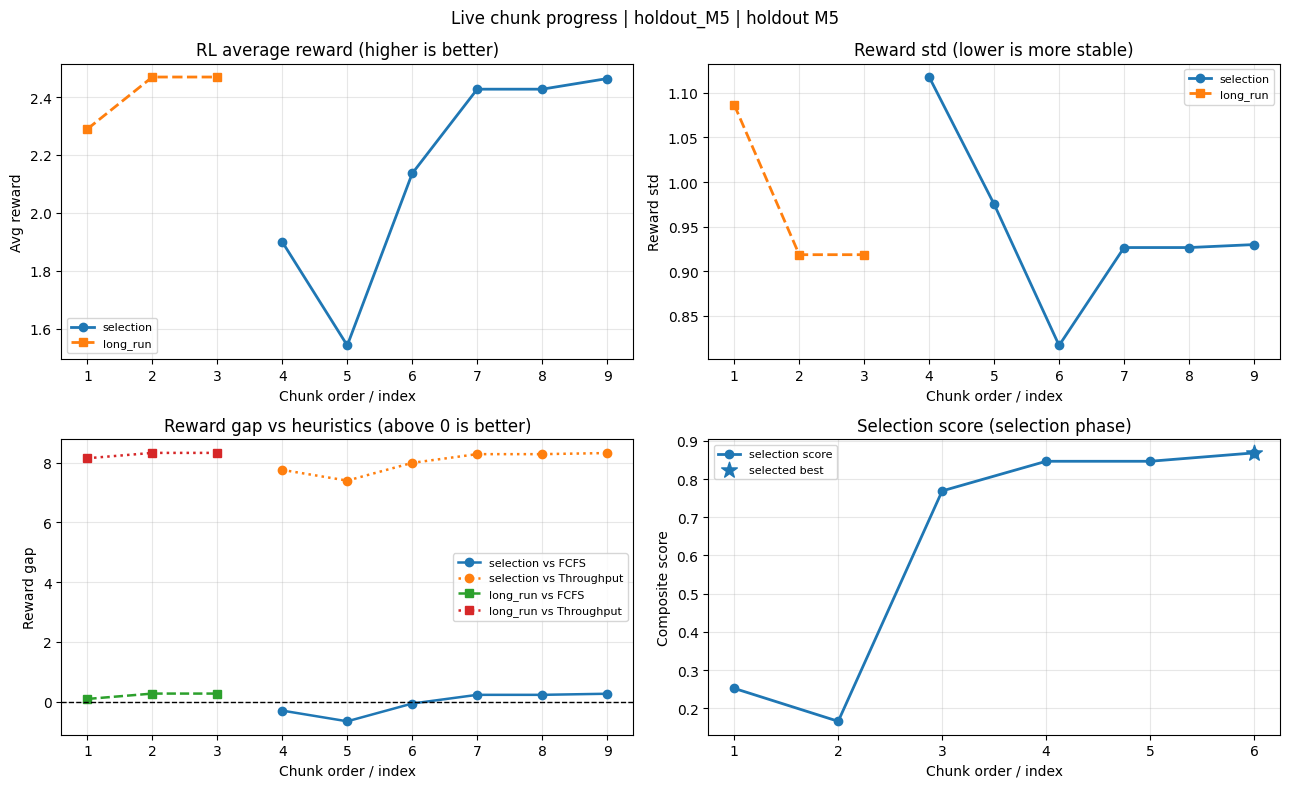

,phase,chunk_idx,timesteps_end,chunk_status_icon,chunk_status,rl_avg_reward,rl_reward_std,rl_minus_fcfs,rl_minus_throughput,rl_minus_best_heur,selection_score
0,selection,1,57344,🟡,watch,1.899336,1.117754,-0.301024,7.757697,-0.301024,0.252079
1,selection,2,114688,🔴,unstable,1.541461,0.975069,-0.658899,7.399822,-0.658899,0.165919
2,selection,3,172032,🟡,watch,2.136243,0.816765,-0.064118,7.994604,-0.064118,0.768951
3,selection,4,229376,🟢,good,2.427585,0.926532,0.227225,8.285946,0.227225,0.846525
4,selection,5,286720,🟢,good,2.427585,0.926532,0.227225,8.285946,0.227225,0.846525
5,selection,6,303104,🟢,good,2.464262,0.929865,0.263902,8.322623,0.263902,0.868483


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[long_run] chunk=04 end_ts=532480 | RL avg=2.470 std=0.919 | Δbest_heur=0.269
Status: 🟢 GOOD | Beating best heuristic and stable (std <= 0.988).
Long-run no-improve streak: 3/3
Early stop: long-run is no longer improving on eval reward.
Live progress snapshot synced to Drive before next holdout: holdout_M5
Saved chunk metrics: output/ppo_chunk_metrics.csv
Saved episode rewards: output/ppo_episode_rewards.csv
Saved experiment summary: output/ppo_metrics.csv
Saved recommended resume points: output/recommended_resume_points.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,run_tag,experiment,held_out_municipality,train_municipalities,profile,chunk_timesteps,initial_phase_total_timesteps,long_run_total_timesteps,selected_checkpoint_path,selected_checkpoint_timestep,...,final_phase,final_timestep,final_rl_avg_reward,final_rl_reward_std,final_rl_minus_fcfs,final_rl_minus_throughput,final_chunk_status,final_chunk_status_icon,resumed_initially,resumed_from
0,20260318_045825,holdout_M1,1,"2,3,4,5",standard,50000,300000,600000,output/ppo_checkpoint/holdout_M1/holdout_M1_se...,286720,...,long_run,516096,1.941569,0.670331,2.475013,6.025053,good,🟢,False,
1,20260318_045825,holdout_M2,2,"1,3,4,5",standard,50000,300000,600000,output/ppo_checkpoint/holdout_M2/holdout_M2_se...,286720,...,long_run,516096,2.613561,0.803924,-0.077117,5.738442,watch,🟡,False,
2,20260318_045825,holdout_M3,3,"1,2,4,5",standard,50000,300000,600000,output/ppo_checkpoint/holdout_M3/holdout_M3_se...,57344,...,long_run,458752,1.386567,1.686036,4.067017,6.488591,good,🟢,False,
3,20260318_045825,holdout_M4,4,"1,2,3,5",standard,50000,300000,600000,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,303104,...,long_run,532480,1.809571,0.900964,4.090331,9.791057,good,🟢,False,
4,20260318_045825,holdout_M5,5,"1,2,3,4",standard,50000,300000,600000,output/ppo_checkpoint/holdout_M5/holdout_M5_se...,303104,...,long_run,532480,2.469642,0.918529,0.269282,8.328003,good,🟢,False,


,experiment,recommended_resume_timestep,nearest_checkpoint_sb3_path,nearest_checkpoint_pt_path,selection_score,rl_avg_reward,rl_reward_std,rl_minus_best_heur,chunk_status,chunk_status_icon
0,holdout_M1,286720,output/ppo_checkpoint/holdout_M1/holdout_M1_se...,output/ppo_checkpoint/holdout_M1/holdout_M1_se...,0.998775,2.086836,0.740867,2.620280,good,🟢
1,holdout_M2,286720,output/ppo_checkpoint/holdout_M2/holdout_M2_se...,output/ppo_checkpoint/holdout_M2/holdout_M2_se...,0.999109,2.763938,0.784817,0.073261,good,🟢
2,holdout_M3,57344,output/ppo_checkpoint/holdout_M3/holdout_M3_se...,output/ppo_checkpoint/holdout_M3/holdout_M3_se...,0.904696,-2.421631,10.029458,0.258819,good,🟢
3,holdout_M4,303104,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,0.998921,2.025051,0.745070,4.305811,good,🟢
4,holdout_M5,303104,output/ppo_checkpoint/holdout_M5/holdout_M5_se...,output/ppo_checkpoint/holdout_M5/holdout_M5_se...,0.868483,2.464262,0.929865,0.263902,good,🟢


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
PPO_METRICS_PATH = OUTPUT_DIR / 'ppo_metrics.csv'
PPO_CHUNK_METRICS_PATH = OUTPUT_DIR / 'ppo_chunk_metrics.csv'
PPO_EPISODE_REWARDS_PATH = OUTPUT_DIR / 'ppo_episode_rewards.csv'
PPO_CHECKPOINT_DIR = OUTPUT_DIR / 'ppo_checkpoint'
PPO_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output/ppo_checkpoint')
DRIVE_OUTPUT_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output')
DRIVE_LIVE_PROGRESS_DIR = DRIVE_OUTPUT_DIR / 'live_progress'
DRIVE_SYNC_ENABLED = bool(IN_COLAB)

RESUME_PLAN_PATH = OUTPUT_DIR / 'recommended_resume_plan.json'
RECOMMENDED_POINTS_PATH = OUTPUT_DIR / 'recommended_resume_points.csv'

LIVE_PLOTS_ENABLED = True
LIVE_PLOTS_CLEAR_OUTPUT = True

if DRIVE_SYNC_ENABLED:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=True)
        DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        DRIVE_LIVE_PROGRESS_DIR.mkdir(parents=True, exist_ok=True)
        print(f'Drive checkpoint sync enabled: {DRIVE_CHECKPOINT_DIR}')
    except Exception as exc:
        DRIVE_SYNC_ENABLED = False
        print(f'Warning: Drive checkpoint sync disabled: {exc}')

resume_plan_by_experiment = {}
if RESUME_PLAN_PATH.exists():
    try:
        resume_payload = json.loads(RESUME_PLAN_PATH.read_text(encoding='utf-8'))
        plan_rows = resume_payload.get('plan', []) if isinstance(resume_payload, dict) else []
        for row in plan_rows:
            if isinstance(row, dict) and row.get('experiment'):
                resume_plan_by_experiment[str(row['experiment'])] = row
        print(f'Loaded resume plan: {RESUME_PLAN_PATH} (entries={len(resume_plan_by_experiment)})')
    except Exception as exc:
        print(f'Warning: failed to parse resume plan ({RESUME_PLAN_PATH}): {exc}')


def _extract_timestep_from_checkpoint_name(path: Path) -> int:
    stem = path.stem
    marker = '_ts'
    idx = stem.rfind(marker)
    if idx < 0:
        return -1
    tail = stem[idx + len(marker):]
    digits = ''.join(ch for ch in tail if ch.isdigit())
    return int(digits) if digits else -1


def _sync_experiment_checkpoints_from_drive(exp_name: str):
    if not DRIVE_SYNC_ENABLED:
        return 0
    src_dir = DRIVE_CHECKPOINT_DIR / exp_name
    dst_dir = PPO_CHECKPOINT_DIR / exp_name
    if not src_dir.exists():
        return 0
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = 0
    for p in src_dir.glob('*'):
        if p.suffix.lower() not in {'.zip', '.pt'}:
            continue
        dst = dst_dir / p.name
        if (not dst.exists()) or (p.stat().st_mtime > dst.stat().st_mtime):
            shutil.copy2(p, dst)
            copied += 1
    return copied


def _find_latest_checkpoint_path(exp_name: str):
    exp_dir = PPO_CHECKPOINT_DIR / exp_name
    if not exp_dir.exists():
        return None
    candidates = list(exp_dir.glob('*.zip'))
    if len(candidates) == 0:
        return None
    candidates.sort(key=lambda p: (_extract_timestep_from_checkpoint_name(p), p.stat().st_mtime), reverse=True)
    return candidates[0]


def _save_live_progress_to_drive(exp_name: str, chunk_rows, results, episode_reward_dfs):
    if not DRIVE_SYNC_ENABLED:
        return
    try:
        DRIVE_LIVE_PROGRESS_DIR.mkdir(parents=True, exist_ok=True)

        chunk_df_live = pd.DataFrame(chunk_rows)
        results_df_live = pd.DataFrame(results)
        if len(episode_reward_dfs) > 0:
            episode_df_live = pd.concat(episode_reward_dfs, ignore_index=True)
        else:
            episode_df_live = pd.DataFrame(columns=['experiment', 'timestep', 'episode_reward', 'episode_length'])

        chunk_live_path = OUTPUT_DIR / 'ppo_chunk_metrics_live.csv'
        results_live_path = OUTPUT_DIR / 'ppo_metrics_live.csv'
        episodes_live_path = OUTPUT_DIR / 'ppo_episode_rewards_live.csv'

        chunk_df_live.to_csv(chunk_live_path, index=False)
        results_df_live.to_csv(results_live_path, index=False)
        episode_df_live.to_csv(episodes_live_path, index=False)

        shutil.copy2(chunk_live_path, DRIVE_LIVE_PROGRESS_DIR / chunk_live_path.name)
        shutil.copy2(results_live_path, DRIVE_LIVE_PROGRESS_DIR / results_live_path.name)
        shutil.copy2(episodes_live_path, DRIVE_LIVE_PROGRESS_DIR / episodes_live_path.name)

        chunk_exp_df = chunk_df_live[chunk_df_live['experiment'] == exp_name].copy()
        if len(chunk_exp_df) > 0:
            exp_chunk_path = OUTPUT_DIR / f'ppo_chunk_metrics_live_{exp_name}.csv'
            chunk_exp_df.to_csv(exp_chunk_path, index=False)
            shutil.copy2(exp_chunk_path, DRIVE_LIVE_PROGRESS_DIR / exp_chunk_path.name)

        print(f'Live progress snapshot synced to Drive before next holdout: {exp_name}')
    except Exception as exc:
        print(f'Warning: failed to save live progress snapshot for {exp_name}: {exc}')


STATUS_ICONS = {
    'good': '🟢',
    'watch': '🟡',
    'unstable': '🔴',
}


def _normalize_series_for_score(s: pd.Series, higher_is_better: bool = True):
    x = s.astype(float)
    xmin, xmax = x.min(), x.max()
    if (not np.isfinite(xmin)) or (not np.isfinite(xmax)) or np.isclose(xmax, xmin):
        base = pd.Series(np.full(len(x), 0.5), index=x.index)
    else:
        base = (x - xmin) / (xmax - xmin)
    return base if higher_is_better else (1.0 - base)


def _score_selection_phase(df_one_exp: pd.DataFrame):
    if len(df_one_exp) == 0:
        return df_one_exp
    out = df_one_exp.copy()
    out['score_reward_mean'] = _normalize_series_for_score(out['rl_avg_reward'], higher_is_better=True)
    out['score_stability'] = _normalize_series_for_score(out['rl_reward_std'], higher_is_better=False)
    out['score_vs_heuristic'] = _normalize_series_for_score(out['rl_minus_best_heur'], higher_is_better=True)
    out['selection_score'] = (
        checkpoint_score_weights['reward_mean'] * out['score_reward_mean'] +
        checkpoint_score_weights['reward_stability'] * out['score_stability'] +
        checkpoint_score_weights['vs_heuristic'] * out['score_vs_heuristic']
    )
    return out


def _classify_chunk_status(rl_minus_best_heur: float, rl_reward_std: float, baseline_std_ref: float):
    good_gap_min = 0.0
    watch_gap_min = -0.5
    good_std_max = 1.15 * baseline_std_ref
    watch_std_max = 1.75 * baseline_std_ref

    if (rl_minus_best_heur >= good_gap_min) and (rl_reward_std <= good_std_max):
        note = f"Beating best heuristic and stable (std <= {good_std_max:.3f})."
        return 'good', note
    if (rl_minus_best_heur >= watch_gap_min) and (rl_reward_std <= watch_std_max):
        note = f"Near baseline or mildly noisy; monitor trend (std <= {watch_std_max:.3f})."
        return 'watch', note
    note = 'Below heuristic and/or unstable variance; avoid using as long-run anchor.'
    return 'unstable', note


def _build_model(train_env, model_seed: int):
    policy_kwargs = dict(
        net_arch=dict(pi=[256, 256, 128], vf=[256, 256, 128]),
        activation_fn=torch.nn.ReLU,
    )

    return MaskablePPO(
        policy='MultiInputPolicy',
        env=train_env,
        device='auto',
        policy_kwargs=policy_kwargs,
        learning_rate=7e-5,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.003,
        clip_range=0.2,
        verbose=0,
        seed=model_seed,
    )


def _save_chunk_checkpoint(model, checkpoint_dir: Path, exp_name: str, phase: str, chunk_idx: int):
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    ts = int(getattr(model, 'num_timesteps', 0))
    stem = f'{exp_name}_{phase}_chunk{chunk_idx:03d}_ts{ts}'
    sb3_path = checkpoint_dir / f'{stem}.zip'
    pt_path = checkpoint_dir / f'{stem}.pt'
    model.save(str(sb3_path))

    optimizer_state = {}
    try:
        optimizer_state = model.policy.optimizer.state_dict()
    except Exception:
        optimizer_state = {}

    torch_payload = {
        'experiment': exp_name,
        'phase': phase,
        'chunk_idx': int(chunk_idx),
        'num_timesteps': ts,
        'policy_state_dict': model.policy.state_dict(),
        'optimizer_state_dict': optimizer_state,
    }
    torch.save(torch_payload, pt_path)

    if DRIVE_SYNC_ENABLED:
        try:
            drive_exp_dir = DRIVE_CHECKPOINT_DIR / exp_name
            drive_exp_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(sb3_path, drive_exp_dir / sb3_path.name)
            shutil.copy2(pt_path, drive_exp_dir / pt_path.name)
        except Exception as exc:
            print(f'Warning: failed to mirror checkpoint to Drive for {exp_name}: {exc}')
    return sb3_path, pt_path, ts


def _render_live_chunk_dashboard(exp_name: str, held_out: int, exp_chunk_df: pd.DataFrame, selected_best_key=None):
    if not LIVE_PLOTS_ENABLED or len(exp_chunk_df) == 0:
        return

    plot_df = exp_chunk_df.sort_values(['phase', 'chunk_idx']).copy()
    plot_df['global_chunk_order'] = np.arange(1, len(plot_df) + 1)

    if LIVE_PLOTS_CLEAR_OUTPUT:
        clear_output(wait=True)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)

    for phase, marker, linestyle in [('selection', 'o', '-'), ('long_run', 's', '--')]:
        g = plot_df[plot_df['phase'] == phase]
        if len(g) == 0:
            continue
        axes[0, 0].plot(g['global_chunk_order'], g['rl_avg_reward'], marker=marker, linestyle=linestyle, linewidth=2, label=phase)
        axes[0, 1].plot(g['global_chunk_order'], g['rl_reward_std'], marker=marker, linestyle=linestyle, linewidth=2, label=phase)
        axes[1, 0].plot(g['global_chunk_order'], g['rl_minus_fcfs'], marker=marker, linestyle=linestyle, linewidth=1.8, label=f'{phase} vs FCFS')
        axes[1, 0].plot(g['global_chunk_order'], g['rl_minus_throughput'], marker=marker, linestyle=':', linewidth=1.8, label=f'{phase} vs Throughput')

    sel = plot_df[plot_df['phase'] == 'selection']
    if len(sel) > 0 and 'selection_score' in sel.columns:
        axes[1, 1].plot(sel['chunk_idx'], sel['selection_score'], marker='o', linewidth=2, label='selection score')
        if selected_best_key is not None:
            cidx, _ = selected_best_key
            best_row = sel[sel['chunk_idx'] == cidx]
            if len(best_row) > 0:
                axes[1, 1].scatter(best_row['chunk_idx'], best_row['selection_score'], s=140, marker='*', zorder=5, label='selected best')

    axes[0, 0].set_title('RL average reward (higher is better)')
    axes[0, 1].set_title('Reward std (lower is more stable)')
    axes[1, 0].set_title('Reward gap vs heuristics (above 0 is better)')
    axes[1, 1].set_title('Selection score (selection phase)')

    axes[1, 0].axhline(0.0, color='black', linestyle='--', linewidth=1)

    for ax in axes.flat:
        ax.grid(alpha=0.3)
        ax.set_xlabel('Chunk order / index')
        ax.legend(loc='best', fontsize=8)

    axes[0, 0].set_ylabel('Avg reward')
    axes[0, 1].set_ylabel('Reward std')
    axes[1, 0].set_ylabel('Reward gap')
    axes[1, 1].set_ylabel('Composite score')

    fig.suptitle(f'Live chunk progress | {exp_name} | holdout M{held_out}')
    plt.tight_layout()
    plt.show()

    latest_cols = [
        'phase', 'chunk_idx', 'timesteps_end', 'chunk_status_icon', 'chunk_status', 'rl_avg_reward', 'rl_reward_std',
        'rl_minus_fcfs', 'rl_minus_throughput', 'rl_minus_best_heur', 'selection_score'
    ]
    display(plot_df[latest_cols].tail(6))


results = []
chunk_rows = []
episode_reward_dfs = []
run_tag = datetime.now().strftime('%Y%m%d_%H%M%S')

for i, exp in enumerate(experiments):
    exp_name = exp['name']
    train_muns = exp['train_municipalities']
    held_out = exp['held_out']

    print('' + '=' * 100)
    print(f'Experiment {i+1}/{len(experiments)}: {exp_name}')
    print(f'Train municipalities: {train_muns} | Held out: M{held_out}')

    train_env = VecMonitor(make_vec_env(train_muns, seed=seed + i * 100, arrival_rate=train_arrival_rate, bonus_scale=train_bonus_scale))

    resumed = False
    resumed_from = ''

    synced = _sync_experiment_checkpoints_from_drive(exp_name)
    if synced > 0:
        print(f'Synced {synced} checkpoint files from Drive for {exp_name}.')

    model = None

    plan_entry = resume_plan_by_experiment.get(exp_name, {})
    plan_ckpt_path = None
    if isinstance(plan_entry, dict):
        ckpt_raw = str(plan_entry.get('checkpoint_path', '') or '').strip()
        if ckpt_raw:
            plan_ckpt_path = Path(ckpt_raw)

    if plan_ckpt_path is not None and plan_ckpt_path.exists():
        print(f'Resuming from plan checkpoint: {plan_ckpt_path}')
        model = MaskablePPO.load(str(plan_ckpt_path), env=train_env, device='auto')
        resumed = True
        resumed_from = str(plan_ckpt_path)

    if model is None:
        latest_ckpt = _find_latest_checkpoint_path(exp_name)
        if latest_ckpt is not None and latest_ckpt.exists():
            print(f'Resuming from latest checkpoint: {latest_ckpt}')
            model = MaskablePPO.load(str(latest_ckpt), env=train_env, device='auto')
            resumed = True
            resumed_from = str(latest_ckpt)
    if model is None:
        model = _build_model(train_env=train_env, model_seed=seed + i)

    baseline_fcfs = evaluate_heuristic_detailed(
        municipality=held_out,
        heuristic_mode='fcfs',
        arrival_rate=eval_arrival_rate,
        episode_seeds=fixed_eval_seeds,
        bonus_scale=eval_bonus_scale,
    )
    baseline_throughput = evaluate_heuristic_detailed(
        municipality=held_out,
        heuristic_mode='throughput',
        arrival_rate=eval_arrival_rate,
        episode_seeds=fixed_eval_seeds,
        bonus_scale=eval_bonus_scale,
    )
    baseline_std_ref = max(1e-6, min(float(baseline_fcfs['reward_std']), float(baseline_throughput['reward_std'])))

    print(
        f"Fixed baselines | FCFS avg={baseline_fcfs['avg_reward']:.3f}, std={baseline_fcfs['reward_std']:.3f} | "
        f"Throughput avg={baseline_throughput['avg_reward']:.3f}, std={baseline_throughput['reward_std']:.3f}"
    )

    exp_ckpt_dir = PPO_CHECKPOINT_DIR / exp_name
    exp_ckpt_dir.mkdir(parents=True, exist_ok=True)

    episode_tracker_cb = EpisodeRewardTrackerCallback(exp_name=exp_name, verbose=0)

    start_ts = int(getattr(model, 'num_timesteps', 0))
    selection_target_timesteps = start_ts + int(initial_phase_total_timesteps)
    print(f'Selection continuation target: start_ts={start_ts}, target_ts={selection_target_timesteps}')
    chunk_idx = 0
    selected_best_key = None

    while int(getattr(model, 'num_timesteps', 0)) < selection_target_timesteps:
        current_ts = int(getattr(model, 'num_timesteps', 0))
        remaining = selection_target_timesteps - current_ts
        this_chunk = int(min(chunk_timesteps, remaining))
        if this_chunk <= 0:
            break

        learn_kwargs = {
            'total_timesteps': this_chunk,
            'callback': episode_tracker_cb,
            'reset_num_timesteps': False,
        }
        t0 = time.time()
        model.learn(**learn_kwargs)
        train_seconds = time.time() - t0

        chunk_idx += 1
        ckpt_sb3, ckpt_pt, end_ts = _save_chunk_checkpoint(
            model=model,
            checkpoint_dir=exp_ckpt_dir,
            exp_name=exp_name,
            phase='selection',
            chunk_idx=chunk_idx,
        )

        rl_eval = evaluate_policy_detailed(
            model=model,
            municipality=held_out,
            arrival_rate=eval_arrival_rate,
            episode_seeds=fixed_eval_seeds,
            bonus_scale=eval_bonus_scale,
        )

        best_heur_avg = max(float(baseline_fcfs['avg_reward']), float(baseline_throughput['avg_reward']))
        rl_minus_best_heur = float(rl_eval['avg_reward'] - best_heur_avg)
        status, status_note = _classify_chunk_status(
            rl_minus_best_heur=rl_minus_best_heur,
            rl_reward_std=float(rl_eval['reward_std']),
            baseline_std_ref=baseline_std_ref,
        )
        row = {
            'run_tag': run_tag,
            'experiment': exp_name,
            'held_out_municipality': held_out,
            'phase': 'selection',
            'chunk_idx': chunk_idx,
            'train_municipalities': ','.join(map(str, train_muns)),
            'timesteps_end': end_ts,
            'chunk_timesteps': this_chunk,
            'chunk_train_seconds': round(train_seconds, 2),
            'checkpoint_path': str(ckpt_sb3),
            'checkpoint_pt_path': str(ckpt_pt),
            'resumed_initially': resumed,
            'resumed_from': resumed_from,
            'eval_episodes': len(fixed_eval_seeds),
            'eval_seeds': ','.join(map(str, fixed_eval_seeds)),
            'rl_avg_reward': float(rl_eval['avg_reward']),
            'rl_reward_std': float(rl_eval['reward_std']),
            'rl_reward_var': float(rl_eval['reward_var']),
            'rl_avg_completed': float(rl_eval['avg_completed']),
            'rl_avg_queue': float(rl_eval['avg_queue']),
            'heur_fcfs_avg_reward': float(baseline_fcfs['avg_reward']),
            'heur_fcfs_reward_std': float(baseline_fcfs['reward_std']),
            'heur_throughput_avg_reward': float(baseline_throughput['avg_reward']),
            'heur_throughput_reward_std': float(baseline_throughput['reward_std']),
            'rl_minus_fcfs': float(rl_eval['avg_reward'] - baseline_fcfs['avg_reward']),
            'rl_minus_throughput': float(rl_eval['avg_reward'] - baseline_throughput['avg_reward']),
            'rl_minus_best_heur': rl_minus_best_heur,
            'selection_score': np.nan,
            'selected_as_best': False,
            'chunk_status': status,
            'chunk_status_icon': STATUS_ICONS[status],
            'chunk_status_note': status_note,
        }
        chunk_rows.append(row)
        print(
            f"[selection] chunk={chunk_idx:02d} end_ts={end_ts} | "
            f"RL avg={row['rl_avg_reward']:.3f} std={row['rl_reward_std']:.3f} | "
            f"Δbest_heur={row['rl_minus_best_heur']:.3f}"
        )
        print(f"Status: {row['chunk_status_icon']} {row['chunk_status'].upper()} | {row['chunk_status_note']}")

        exp_live_df = pd.DataFrame([r for r in chunk_rows if r['experiment'] == exp_name])
        _render_live_chunk_dashboard(exp_name=exp_name, held_out=held_out, exp_chunk_df=exp_live_df, selected_best_key=selected_best_key)

    exp_chunk_df = pd.DataFrame([r for r in chunk_rows if r['experiment'] == exp_name and r['phase'] == 'selection'])
    if len(exp_chunk_df) == 0:
        raise RuntimeError(f'No selection-phase chunks were produced for {exp_name}.')

    scored_df = _score_selection_phase(exp_chunk_df)
    best_idx = scored_df['selection_score'].astype(float).idxmax()
    best_row = scored_df.loc[best_idx].to_dict()

    score_lookup = {
        (int(r['chunk_idx']), int(r['timesteps_end'])): float(r['selection_score'])
        for _, r in scored_df.iterrows()
    }
    best_key = (int(best_row['chunk_idx']), int(best_row['timesteps_end']))
    selected_best_key = best_key
    for r in chunk_rows:
        if r['experiment'] == exp_name and r['phase'] == 'selection':
            key = (int(r['chunk_idx']), int(r['timesteps_end']))
            r['selection_score'] = score_lookup.get(key, np.nan)
            r['selected_as_best'] = (key == best_key)

    best_ckpt_path = Path(best_row['checkpoint_path'])
    print(
        f"Selected best checkpoint for {exp_name}: chunk={int(best_row['chunk_idx'])}, "
        f"ts={int(best_row['timesteps_end'])}, score={float(best_row['selection_score']):.4f}"
    )

    exp_live_df = pd.DataFrame([r for r in chunk_rows if r['experiment'] == exp_name])
    _render_live_chunk_dashboard(exp_name=exp_name, held_out=held_out, exp_chunk_df=exp_live_df, selected_best_key=selected_best_key)

    model = MaskablePPO.load(str(best_ckpt_path), env=train_env, device='auto')
    long_target_ts = int(getattr(model, 'num_timesteps', 0)) + int(long_run_total_timesteps)
    long_chunk_idx = 0
    best_long_run_reward = -np.inf
    worse_long_run_streak = 0

    while enable_long_run and int(getattr(model, 'num_timesteps', 0)) < long_target_ts:
        current_ts = int(getattr(model, 'num_timesteps', 0))
        remaining = long_target_ts - current_ts
        this_chunk = int(min(long_run_chunk_timesteps, remaining))
        if this_chunk <= 0:
            break

        learn_kwargs = {
            'total_timesteps': this_chunk,
            'callback': episode_tracker_cb,
            'reset_num_timesteps': False,
        }
        t0 = time.time()
        model.learn(**learn_kwargs)
        train_seconds = time.time() - t0

        long_chunk_idx += 1
        ckpt_sb3, ckpt_pt, end_ts = _save_chunk_checkpoint(
            model=model,
            checkpoint_dir=exp_ckpt_dir,
            exp_name=exp_name,
            phase='long_run',
            chunk_idx=long_chunk_idx,
        )

        rl_eval = evaluate_policy_detailed(
            model=model,
            municipality=held_out,
            arrival_rate=eval_arrival_rate,
            episode_seeds=fixed_eval_seeds,
            bonus_scale=eval_bonus_scale,
        )

        best_heur_avg = max(float(baseline_fcfs['avg_reward']), float(baseline_throughput['avg_reward']))
        rl_minus_best_heur = float(rl_eval['avg_reward'] - best_heur_avg)
        status, status_note = _classify_chunk_status(
            rl_minus_best_heur=rl_minus_best_heur,
            rl_reward_std=float(rl_eval['reward_std']),
            baseline_std_ref=baseline_std_ref,
        )
        row = {
            'run_tag': run_tag,
            'experiment': exp_name,
            'held_out_municipality': held_out,
            'phase': 'long_run',
            'chunk_idx': long_chunk_idx,
            'train_municipalities': ','.join(map(str, train_muns)),
            'timesteps_end': end_ts,
            'chunk_timesteps': this_chunk,
            'chunk_train_seconds': round(train_seconds, 2),
            'checkpoint_path': str(ckpt_sb3),
            'checkpoint_pt_path': str(ckpt_pt),
            'resumed_initially': resumed,
            'resumed_from': resumed_from,
            'eval_episodes': len(fixed_eval_seeds),
            'eval_seeds': ','.join(map(str, fixed_eval_seeds)),
            'rl_avg_reward': float(rl_eval['avg_reward']),
            'rl_reward_std': float(rl_eval['reward_std']),
            'rl_reward_var': float(rl_eval['reward_var']),
            'rl_avg_completed': float(rl_eval['avg_completed']),
            'rl_avg_queue': float(rl_eval['avg_queue']),
            'heur_fcfs_avg_reward': float(baseline_fcfs['avg_reward']),
            'heur_fcfs_reward_std': float(baseline_fcfs['reward_std']),
            'heur_throughput_avg_reward': float(baseline_throughput['avg_reward']),
            'heur_throughput_reward_std': float(baseline_throughput['reward_std']),
            'rl_minus_fcfs': float(rl_eval['avg_reward'] - baseline_fcfs['avg_reward']),
            'rl_minus_throughput': float(rl_eval['avg_reward'] - baseline_throughput['avg_reward']),
            'rl_minus_best_heur': rl_minus_best_heur,
            'selection_score': np.nan,
            'selected_as_best': False,
            'chunk_status': status,
            'chunk_status_icon': STATUS_ICONS[status],
            'chunk_status_note': status_note,
        }
        chunk_rows.append(row)
        print(
            f"[long_run] chunk={long_chunk_idx:02d} end_ts={end_ts} | "
            f"RL avg={row['rl_avg_reward']:.3f} std={row['rl_reward_std']:.3f} | "
            f"Δbest_heur={row['rl_minus_best_heur']:.3f}"
        )
        print(f"Status: {row['chunk_status_icon']} {row['chunk_status'].upper()} | {row['chunk_status_note']}")

        if float(row['rl_avg_reward']) > float(best_long_run_reward) + float(min_delta_reward):
            best_long_run_reward = float(row['rl_avg_reward'])
            worse_long_run_streak = 0
        else:
            worse_long_run_streak += 1
            print(f"Long-run no-improve streak: {worse_long_run_streak}/{early_stop_patience}")

        if worse_long_run_streak >= int(early_stop_patience):
            print('Early stop: long-run is no longer improving on eval reward.')
            break

        exp_live_df = pd.DataFrame([r for r in chunk_rows if r['experiment'] == exp_name])
        _render_live_chunk_dashboard(exp_name=exp_name, held_out=held_out, exp_chunk_df=exp_live_df, selected_best_key=selected_best_key)

    final_rows = [r for r in chunk_rows if r['experiment'] == exp_name and r['phase'] == 'long_run']
    if len(final_rows) == 0:
        final_row = best_row
        final_phase = 'selection_only'
    else:
        final_row = final_rows[-1]
        final_phase = 'long_run'

    results.append({
        'run_tag': run_tag,
        'experiment': exp_name,
        'held_out_municipality': held_out,
        'train_municipalities': ','.join(map(str, train_muns)),
        'profile': training_profile,
        'chunk_timesteps': chunk_timesteps,
        'initial_phase_total_timesteps': initial_phase_total_timesteps,
        'long_run_total_timesteps': long_run_total_timesteps,
        'selected_checkpoint_path': str(best_ckpt_path),
        'selected_checkpoint_timestep': int(best_row['timesteps_end']),
        'selected_checkpoint_score': float(best_row['selection_score']),
        'final_phase': final_phase,
        'final_timestep': int(final_row['timesteps_end']),
        'final_rl_avg_reward': float(final_row['rl_avg_reward']),
        'final_rl_reward_std': float(final_row['rl_reward_std']),
        'final_rl_minus_fcfs': float(final_row['rl_minus_fcfs']),
        'final_rl_minus_throughput': float(final_row['rl_minus_throughput']),
        'final_chunk_status': str(final_row.get('chunk_status', 'watch')),
        'final_chunk_status_icon': str(final_row.get('chunk_status_icon', STATUS_ICONS['watch'])),
        'resumed_initially': resumed,
        'resumed_from': resumed_from,
    })

    episode_rewards_exp = episode_tracker_cb.to_dataframe()
    if len(episode_rewards_exp) > 0:
        episode_reward_dfs.append(episode_rewards_exp)

    _save_live_progress_to_drive(
        exp_name=exp_name,
        chunk_rows=chunk_rows,
        results=results,
        episode_reward_dfs=episode_reward_dfs,
    )


chunk_metrics_df = pd.DataFrame(chunk_rows)
chunk_metrics_df.to_csv(PPO_CHUNK_METRICS_PATH, index=False)
print('Saved chunk metrics:', PPO_CHUNK_METRICS_PATH)

if len(episode_reward_dfs) > 0:
    episode_rewards_df = pd.concat(episode_reward_dfs, ignore_index=True)
else:
    episode_rewards_df = pd.DataFrame(columns=['experiment', 'timestep', 'episode_reward', 'episode_length'])
episode_rewards_df.to_csv(PPO_EPISODE_REWARDS_PATH, index=False)
print('Saved episode rewards:', PPO_EPISODE_REWARDS_PATH)

results_df = pd.DataFrame(results)
results_df.to_csv(PPO_METRICS_PATH, index=False)
print('Saved experiment summary:', PPO_METRICS_PATH)

selection_best_df = (
    chunk_metrics_df[chunk_metrics_df['phase'] == 'selection']
    .sort_values(['experiment', 'selection_score'], ascending=[True, False])
    .groupby('experiment', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

recommended_resume_df = selection_best_df[[
    'experiment',
    'timesteps_end',
    'checkpoint_path',
    'checkpoint_pt_path',
    'selection_score',
    'rl_avg_reward',
    'rl_reward_std',
    'rl_minus_best_heur',
    'chunk_status',
    'chunk_status_icon',
]].rename(columns={
    'timesteps_end': 'recommended_resume_timestep',
    'checkpoint_path': 'nearest_checkpoint_sb3_path',
    'checkpoint_pt_path': 'nearest_checkpoint_pt_path',
})
recommended_resume_df.to_csv(RECOMMENDED_POINTS_PATH, index=False)
print('Saved recommended resume points:', RECOMMENDED_POINTS_PATH)

display(results_df)
display(recommended_resume_df)

In [14]:
if 'chunk_metrics_df' not in globals() or chunk_metrics_df is None or len(chunk_metrics_df) == 0:
    chunk_path = OUTPUT_DIR / 'ppo_chunk_metrics.csv'
    if chunk_path.exists():
        chunk_metrics_df = pd.read_csv(chunk_path)
    else:
        chunk_metrics_df = pd.DataFrame()

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    metrics_path = OUTPUT_DIR / 'ppo_metrics.csv'
    if metrics_path.exists():
        results_df = pd.read_csv(metrics_path)
    else:
        results_df = pd.DataFrame()

if len(chunk_metrics_df) == 0:
    print('No chunk metrics found yet.')
else:
    best_selection = (
        chunk_metrics_df[chunk_metrics_df['phase'] == 'selection']
        .sort_values(['experiment', 'selection_score'], ascending=[True, False])
        .groupby('experiment', as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    show_cols = [
        'experiment', 'timesteps_end', 'chunk_status_icon', 'chunk_status', 'selection_score',
        'rl_avg_reward', 'rl_reward_std', 'rl_minus_fcfs', 'rl_minus_throughput'
    ]
    print('Best selection-phase checkpoint per holdout:')
    display(best_selection[show_cols])

if len(results_df) == 0:
    print('No final experiment summary yet.')
else:
    summary_cols = [
        'experiment', 'selected_checkpoint_timestep', 'selected_checkpoint_score',
        'final_timestep', 'final_chunk_status_icon', 'final_chunk_status',
        'final_rl_avg_reward', 'final_rl_reward_std',
        'final_rl_minus_fcfs', 'final_rl_minus_throughput'
    ]
    display(results_df[summary_cols])

Best selection-phase checkpoint per holdout:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,experiment,timesteps_end,chunk_status_icon,chunk_status,selection_score,rl_avg_reward,rl_reward_std,rl_minus_fcfs,rl_minus_throughput
0,holdout_M1,286720,🟢,good,0.998775,2.086836,0.740867,2.620280,6.170320
1,holdout_M2,286720,🟢,good,0.999109,2.763938,0.784817,0.073261,5.888820
2,holdout_M3,57344,🟢,good,0.904696,-2.421631,10.029458,0.258819,2.680393
3,holdout_M4,303104,🟢,good,0.998921,2.025051,0.745070,4.305811,10.006536
4,holdout_M5,303104,🟢,good,0.868483,2.464262,0.929865,0.263902,8.322623


,experiment,selected_checkpoint_timestep,selected_checkpoint_score,final_timestep,final_chunk_status_icon,final_chunk_status,final_rl_avg_reward,final_rl_reward_std,final_rl_minus_fcfs,final_rl_minus_throughput
0,holdout_M1,286720,0.998775,516096,🟢,good,1.941569,0.670331,2.475013,6.025053
1,holdout_M2,286720,0.999109,516096,🟡,watch,2.613561,0.803924,-0.077117,5.738442
2,holdout_M3,57344,0.904696,458752,🟢,good,1.386567,1.686036,4.067017,6.488591
3,holdout_M4,303104,0.998921,532480,🟢,good,1.809571,0.900964,4.090331,9.791057
4,holdout_M5,303104,0.868483,532480,🟢,good,2.469642,0.918529,0.269282,8.328003


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Live chunk dashboard + traffic-light status guide

The training cell updates charts **after every chunk** and prints a status line:
- **🟢 GOOD**: strong and stable chunk (better than best heuristic with controlled variance).
- **🟡 WATCH**: usable but uncertain (near heuristic or somewhat noisy).
- **🔴 UNSTABLE**: weak anchor (below heuristic and/or high variance).

How status is computed (simple):
- Compare RL mean reward to the **best heuristic** mean (`RL - best_heur`).
- Compare RL reward std to a **baseline std reference** from heuristics.
- Thresholds are adaptive per holdout:
  - GOOD if `RL - best_heur >= 0` and `RL std <= 1.15 x baseline_std_ref`
  - WATCH if `RL - best_heur >= -0.5` and `RL std <= 1.75 x baseline_std_ref`
  - Else UNSTABLE

What each chart represents and what to watch:

1. **RL average reward by chunk**
- Mean return on fixed evaluation seeds for each checkpoint.
- Prefer upward trend; sharp repeated reversals suggest unstable learning.

2. **Reward standard deviation by chunk**
- Cross-episode variability on fixed evaluation seeds.
- Lower is better; sustained spikes indicate brittle policy behavior.

3. **RL - FCFS and RL - Throughput**
- Margin over heuristic baselines on the same fixed setup.
- Above 0 means RL is outperforming that heuristic.

4. **Selection score (selection phase only)**
- Composite score balancing reward level, stability, and baseline gap.
- Starred checkpoint is selected for long-run continuation.

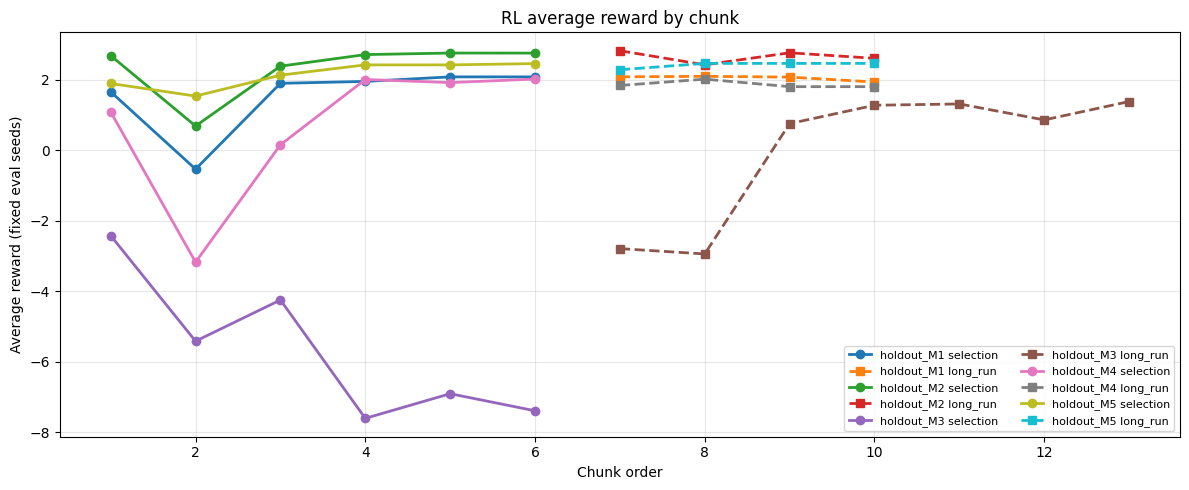

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


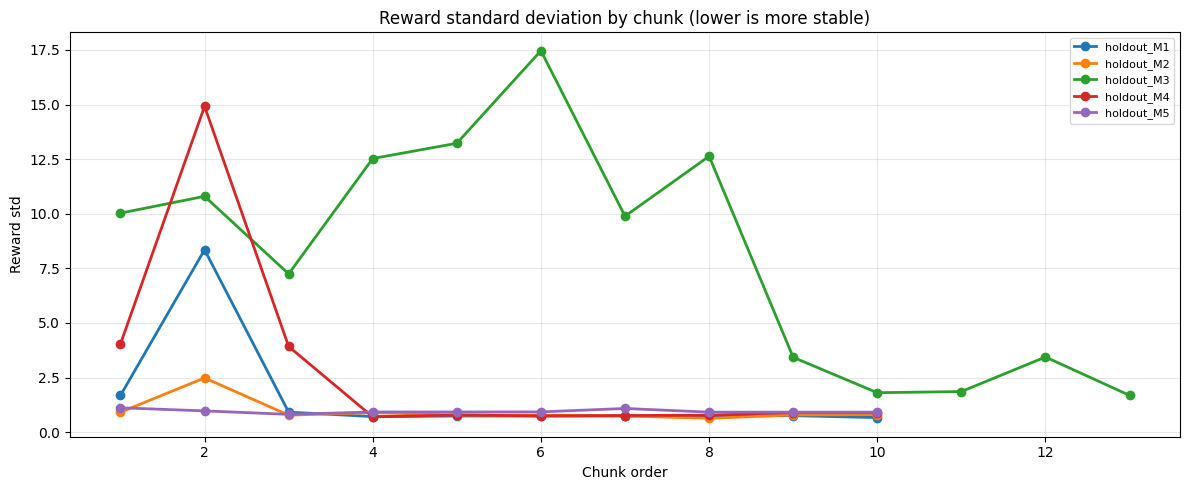

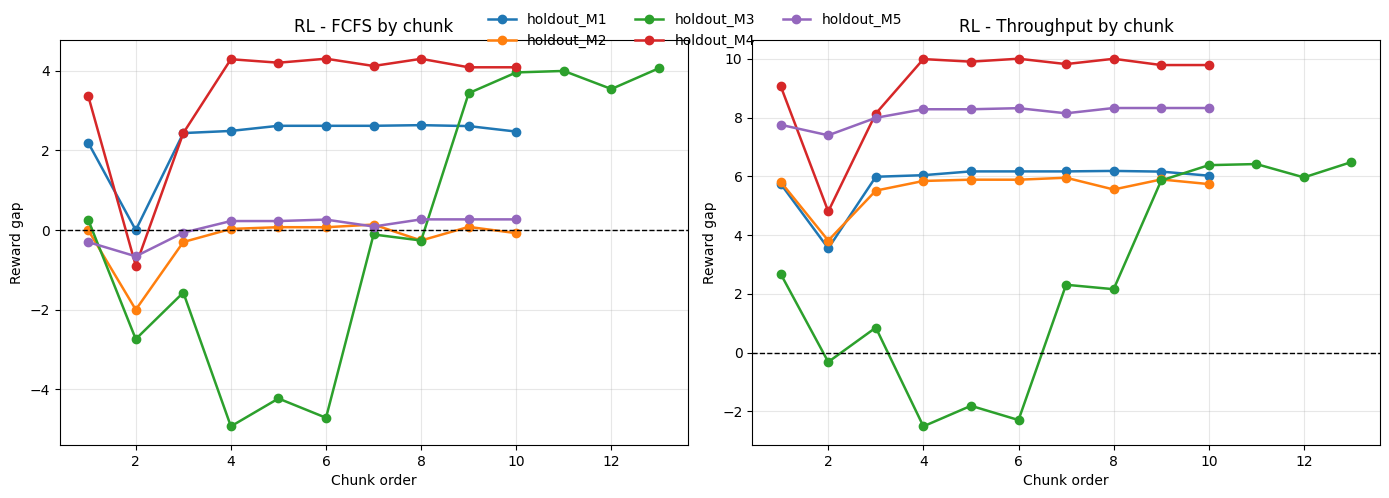

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


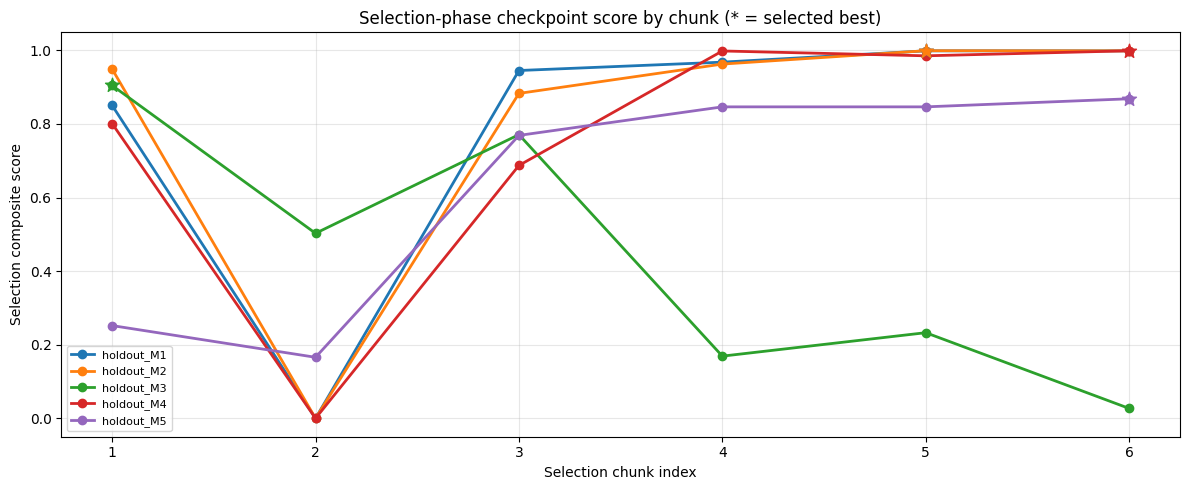

,run_tag,experiment,held_out_municipality,phase,chunk_idx,train_municipalities,timesteps_end,chunk_timesteps,chunk_train_seconds,checkpoint_path,...,heur_throughput_reward_std,rl_minus_fcfs,rl_minus_throughput,rl_minus_best_heur,selection_score,selected_as_best,chunk_status,chunk_status_icon,chunk_status_note,global_chunk_order
39,20260318_045825,holdout_M4,4,long_run,1,"1,2,3,5",360448,50000,75.98,output/ppo_checkpoint/holdout_M4/holdout_M4_lo...,...,18.093110,4.123328,9.824053,4.123328,NaN,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,7
40,20260318_045825,holdout_M4,4,long_run,2,"1,2,3,5",417792,50000,75.18,output/ppo_checkpoint/holdout_M4/holdout_M4_lo...,...,18.093110,4.303208,10.003934,4.303208,NaN,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,8
41,20260318_045825,holdout_M4,4,long_run,3,"1,2,3,5",475136,50000,77.91,output/ppo_checkpoint/holdout_M4/holdout_M4_lo...,...,18.093110,4.090061,9.790787,4.090061,NaN,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,9
42,20260318_045825,holdout_M4,4,long_run,4,"1,2,3,5",532480,50000,78.86,output/ppo_checkpoint/holdout_M4/holdout_M4_lo...,...,18.093110,4.090331,9.791057,4.090331,NaN,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,10
33,20260318_045825,holdout_M4,4,selection,1,"1,2,3,5",57344,50000,73.17,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,...,18.093110,3.372558,9.073283,3.372558,0.801109,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,1
34,20260318_045825,holdout_M4,4,selection,2,"1,2,3,5",114688,50000,74.49,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,...,18.093110,-0.893958,4.806768,-0.893958,0.000000,False,unstable,🔴,Below heuristic and/or unstable variance; avoi...,2
35,20260318_045825,holdout_M4,4,selection,3,"1,2,3,5",172032,50000,74.98,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,...,18.093110,2.438699,8.139425,2.438699,0.687276,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,3
36,20260318_045825,holdout_M4,4,selection,4,"1,2,3,5",229376,50000,74.77,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,...,18.093110,4.293081,9.993806,4.293081,0.998409,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,4
37,20260318_045825,holdout_M4,4,selection,5,"1,2,3,5",286720,50000,77.11,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,...,18.093110,4.205649,9.906374,4.205649,0.985267,False,good,🟢,Beating best heuristic and stable (std <= 14.8...,5
38,20260318_045825,holdout_M4,4,selection,6,"1,2,3,5",303104,13280,22.20,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,...,18.093110,4.305811,10.006536,4.305811,0.998921,True,good,🟢,Beating best heuristic and stable (std <= 14.8...,6


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
if 'chunk_metrics_df' not in globals() or chunk_metrics_df is None or len(chunk_metrics_df) == 0:
    chunk_path = OUTPUT_DIR / 'ppo_chunk_metrics.csv'
    if chunk_path.exists():
        chunk_metrics_df = pd.read_csv(chunk_path)
    else:
        chunk_metrics_df = pd.DataFrame()

if len(chunk_metrics_df) == 0:
    print('No chunk metrics available yet. Run training first.')
else:
    df = chunk_metrics_df.copy()
    df['global_chunk_order'] = df.groupby(['experiment']).cumcount() + 1

    # 1) RL average reward trend
    fig, ax = plt.subplots(figsize=(12, 5))
    for exp_name, g in df.groupby('experiment'):
        gs = g.sort_values('global_chunk_order')
        sel = gs[gs['phase'] == 'selection']
        lng = gs[gs['phase'] == 'long_run']
        ax.plot(sel['global_chunk_order'], sel['rl_avg_reward'], marker='o', linewidth=2, label=f'{exp_name} selection')
        if len(lng) > 0:
            ax.plot(lng['global_chunk_order'], lng['rl_avg_reward'], marker='s', linestyle='--', linewidth=2, label=f'{exp_name} long_run')
    ax.set_title('RL average reward by chunk')
    ax.set_xlabel('Chunk order')
    ax.set_ylabel('Average reward (fixed eval seeds)')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # 2) Reward stability trend (std)
    fig, ax = plt.subplots(figsize=(12, 5))
    for exp_name, g in df.groupby('experiment'):
        gs = g.sort_values('global_chunk_order')
        ax.plot(gs['global_chunk_order'], gs['rl_reward_std'], marker='o', linewidth=2, label=exp_name)
    ax.set_title('Reward standard deviation by chunk (lower is more stable)')
    ax.set_xlabel('Chunk order')
    ax.set_ylabel('Reward std')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    # 3) Improvement over heuristics
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for exp_name, g in df.groupby('experiment'):
        gs = g.sort_values('global_chunk_order')
        axes[0].plot(gs['global_chunk_order'], gs['rl_minus_fcfs'], marker='o', linewidth=1.8, label=exp_name)
        axes[1].plot(gs['global_chunk_order'], gs['rl_minus_throughput'], marker='o', linewidth=1.8, label=exp_name)

    axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('RL - FCFS by chunk')
    axes[1].set_title('RL - Throughput by chunk')
    axes[0].set_xlabel('Chunk order')
    axes[1].set_xlabel('Chunk order')
    axes[0].set_ylabel('Reward gap')
    axes[1].set_ylabel('Reward gap')
    axes[0].grid(alpha=0.3)
    axes[1].grid(alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    if len(handles) > 0:
        fig.legend(handles, labels, loc='upper center', ncol=min(3, len(labels)), frameon=False)
    plt.tight_layout()
    plt.show()

    # 4) Selection score with chosen checkpoint marker
    sel_df = df[df['phase'] == 'selection'].copy()
    if len(sel_df) > 0 and 'selection_score' in sel_df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        for exp_name, g in sel_df.groupby('experiment'):
            gs = g.sort_values('chunk_idx')
            ax.plot(gs['chunk_idx'], gs['selection_score'], marker='o', linewidth=2, label=exp_name)
            chosen = gs[gs['selected_as_best'] == True]
            if len(chosen) > 0:
                ax.scatter(chosen['chunk_idx'], chosen['selection_score'], s=110, marker='*', zorder=5)
        ax.set_title('Selection-phase checkpoint score by chunk (* = selected best)')
        ax.set_xlabel('Selection chunk index')
        ax.set_ylabel('Selection composite score')
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=8)
        plt.tight_layout()
        plt.show()

    display(df.sort_values(['experiment', 'phase', 'chunk_idx']).tail(20))

## Checkpoint selector audit (stable + strong, not only max reward)

This cell rebuilds the recommended checkpoint table from `ppo_chunk_metrics.csv` using the same composite score components:
- reward mean (higher better)
- reward stability via std (lower better)
- performance gap vs best heuristic (higher better)

It also shows a side-by-side comparison between selected checkpoint metrics and final long-run metrics.

,experiment,chunk_idx,timesteps_end,selection_score,rl_avg_reward,rl_reward_std,rl_minus_fcfs,rl_minus_throughput,rl_minus_best_heur,checkpoint_path,checkpoint_pt_path
0,holdout_M1,5,286720,0.998775,2.086836,0.740867,2.620280,6.170320,2.620280,output/ppo_checkpoint/holdout_M1/holdout_M1_se...,output/ppo_checkpoint/holdout_M1/holdout_M1_se...
1,holdout_M2,5,286720,0.999109,2.763938,0.784817,0.073261,5.888820,0.073261,output/ppo_checkpoint/holdout_M2/holdout_M2_se...,output/ppo_checkpoint/holdout_M2/holdout_M2_se...
2,holdout_M3,1,57344,0.904696,-2.421631,10.029458,0.258819,2.680393,0.258819,output/ppo_checkpoint/holdout_M3/holdout_M3_se...,output/ppo_checkpoint/holdout_M3/holdout_M3_se...
3,holdout_M4,6,303104,0.998921,2.025051,0.745070,4.305811,10.006536,4.305811,output/ppo_checkpoint/holdout_M4/holdout_M4_se...,output/ppo_checkpoint/holdout_M4/holdout_M4_se...
4,holdout_M5,6,303104,0.868483,2.464262,0.929865,0.263902,8.322623,0.263902,output/ppo_checkpoint/holdout_M5/holdout_M5_se...,output/ppo_checkpoint/holdout_M5/holdout_M5_se...


Saved recommended resume points: output/recommended_resume_points.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,experiment,timesteps_end,final_timestep,rl_avg_reward,final_rl_avg_reward,improvement_vs_selected_reward,rl_reward_std,final_rl_reward_std,stability_change_vs_selected,rl_minus_fcfs,final_rl_minus_fcfs,rl_minus_throughput,final_rl_minus_throughput
0,holdout_M1,286720,516096,2.086836,1.941569,-0.145267,0.740867,0.670331,-0.070536,2.620280,2.475013,6.170320,6.025053
1,holdout_M2,286720,516096,2.763938,2.613561,-0.150377,0.784817,0.803924,0.019107,0.073261,-0.077117,5.888820,5.738442
2,holdout_M3,57344,458752,-2.421631,1.386567,3.808198,10.029458,1.686036,-8.343422,0.258819,4.067017,2.680393,6.488591
3,holdout_M4,303104,532480,2.025051,1.809571,-0.215480,0.745070,0.900964,0.155894,4.305811,4.090331,10.006536,9.791057
4,holdout_M5,303104,532480,2.464262,2.469642,0.005380,0.929865,0.918529,-0.011336,0.263902,0.269282,8.322623,8.328003


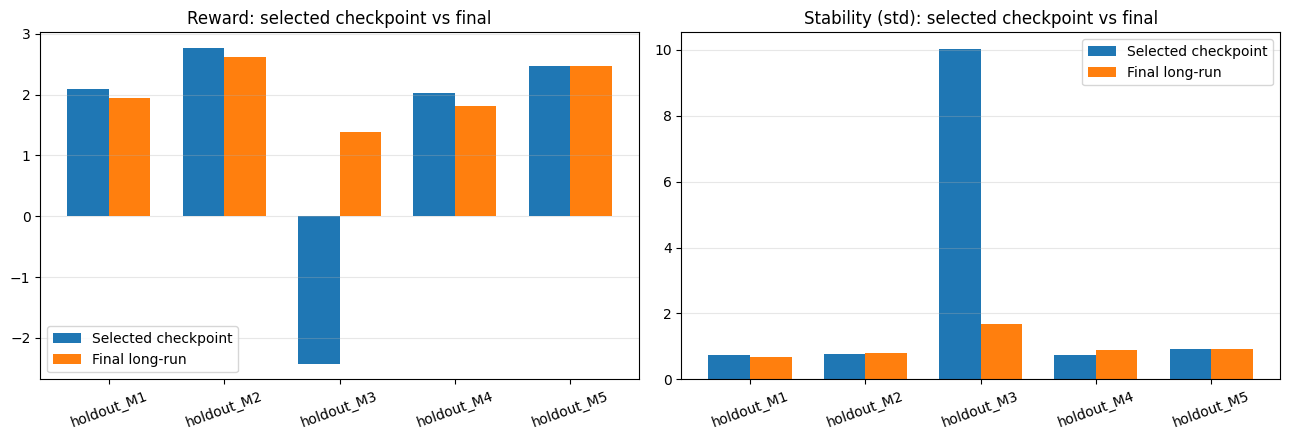

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
chunk_path = OUTPUT_DIR / 'ppo_chunk_metrics.csv'
metrics_path = OUTPUT_DIR / 'ppo_metrics.csv'
rec_path = OUTPUT_DIR / 'recommended_resume_points.csv'

if not chunk_path.exists():
    raise FileNotFoundError(f'Missing chunk metrics: {chunk_path}. Run training cell first.')

chunk_metrics_df = pd.read_csv(chunk_path)
if len(chunk_metrics_df) == 0:
    raise ValueError('Chunk metrics CSV is empty.')

sel_df = chunk_metrics_df[chunk_metrics_df['phase'] == 'selection'].copy()
if len(sel_df) == 0:
    raise ValueError('No selection-phase rows found in chunk metrics.')

# Rebuild score columns defensively (works even if score columns are missing)
def _norm_col(s: pd.Series, higher=True):
    x = s.astype(float)
    xmin, xmax = x.min(), x.max()
    if (not np.isfinite(xmin)) or (not np.isfinite(xmax)) or np.isclose(xmin, xmax):
        out = pd.Series(np.full(len(x), 0.5), index=x.index)
    else:
        out = (x - xmin) / (xmax - xmin)
    return out if higher else (1.0 - out)

rescored = []
for exp_name, g in sel_df.groupby('experiment'):
    gg = g.copy().sort_values('chunk_idx')
    gg['score_reward_mean'] = _norm_col(gg['rl_avg_reward'], higher=True)
    gg['score_stability'] = _norm_col(gg['rl_reward_std'], higher=False)
    gg['score_vs_heuristic'] = _norm_col(gg['rl_minus_best_heur'], higher=True)
    gg['selection_score'] = (
        checkpoint_score_weights['reward_mean'] * gg['score_reward_mean'] +
        checkpoint_score_weights['reward_stability'] * gg['score_stability'] +
        checkpoint_score_weights['vs_heuristic'] * gg['score_vs_heuristic']
    )
    gg['selected_as_best'] = False
    best_ix = gg['selection_score'].idxmax()
    gg.loc[best_ix, 'selected_as_best'] = True
    rescored.append(gg)

sel_rescored_df = pd.concat(rescored, ignore_index=True)
selected_df = (
    sel_rescored_df[sel_rescored_df['selected_as_best'] == True]
    .sort_values('experiment')
    .reset_index(drop=True)
)

audit_cols = [
    'experiment', 'chunk_idx', 'timesteps_end', 'selection_score',
    'rl_avg_reward', 'rl_reward_std', 'rl_minus_fcfs', 'rl_minus_throughput', 'rl_minus_best_heur',
    'checkpoint_path', 'checkpoint_pt_path'
]
display(selected_df[audit_cols])

recommended_resume_df = selected_df[[
    'experiment', 'timesteps_end', 'checkpoint_path', 'checkpoint_pt_path',
    'selection_score', 'rl_avg_reward', 'rl_reward_std', 'rl_minus_best_heur'
]].rename(columns={
    'timesteps_end': 'recommended_resume_timestep',
    'checkpoint_path': 'nearest_checkpoint_sb3_path',
    'checkpoint_pt_path': 'nearest_checkpoint_pt_path',
})
recommended_resume_df.to_csv(rec_path, index=False)
print(f'Saved recommended resume points: {rec_path}')

if metrics_path.exists():
    final_df = pd.read_csv(metrics_path)
    compare = selected_df.merge(
        final_df[['experiment', 'final_timestep', 'final_rl_avg_reward', 'final_rl_reward_std', 'final_rl_minus_fcfs', 'final_rl_minus_throughput']],
        on='experiment',
        how='left'
    )
    compare['improvement_vs_selected_reward'] = compare['final_rl_avg_reward'] - compare['rl_avg_reward']
    compare['stability_change_vs_selected'] = compare['final_rl_reward_std'] - compare['rl_reward_std']
    display(compare[[
        'experiment',
        'timesteps_end', 'final_timestep',
        'rl_avg_reward', 'final_rl_avg_reward', 'improvement_vs_selected_reward',
        'rl_reward_std', 'final_rl_reward_std', 'stability_change_vs_selected',
        'rl_minus_fcfs', 'final_rl_minus_fcfs',
        'rl_minus_throughput', 'final_rl_minus_throughput',
    ]])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    x = np.arange(len(compare))
    labels = compare['experiment'].tolist()

    axes[0].bar(x - 0.18, compare['rl_avg_reward'], width=0.36, label='Selected checkpoint')
    axes[0].bar(x + 0.18, compare['final_rl_avg_reward'], width=0.36, label='Final long-run')
    axes[0].set_title('Reward: selected checkpoint vs final')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20)
    axes[0].grid(alpha=0.3, axis='y')
    axes[0].legend()

    axes[1].bar(x - 0.18, compare['rl_reward_std'], width=0.36, label='Selected checkpoint')
    axes[1].bar(x + 0.18, compare['final_rl_reward_std'], width=0.36, label='Final long-run')
    axes[1].set_title('Stability (std): selected checkpoint vs final')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20)
    axes[1].grid(alpha=0.3, axis='y')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print(f'No final metrics file at {metrics_path}; run training first to compare selected vs final.')

## Build per-holdout resume plan from recommendations

This helper reads `output/recommended_resume_points.csv` and creates a clean resume plan per holdout.
Use it before re-running training to confirm which checkpoint/timestep to resume from for each experiment.

In [37]:
import json
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path('output')
resume_csv = OUTPUT_DIR / 'recommended_resume_points.csv'
resume_json = OUTPUT_DIR / 'recommended_resume_plan.json'

if not resume_csv.exists():
    raise FileNotFoundError(f'Missing recommendations file: {resume_csv}. Run the previous analysis cell first.')

rec_df = pd.read_csv(resume_csv)
if len(rec_df) == 0:
    raise ValueError('Recommendations CSV is empty.')

required_cols = ['experiment', 'recommended_resume_timestep']
missing_cols = [c for c in required_cols if c not in rec_df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in recommendations CSV: {missing_cols}')

plan_rows = []
for _, row in rec_df.sort_values('experiment').iterrows():
    exp_name = str(row['experiment'])
    target_timestep = int(row['recommended_resume_timestep'])
    ckpt_path = str(row.get('nearest_checkpoint_sb3_path', '') or '').strip()
    pt_path = str(row.get('nearest_checkpoint_pt_path', '') or '').strip()

    has_checkpoint = bool(ckpt_path) and Path(ckpt_path).exists()
    plan_rows.append({
        'experiment': exp_name,
        'resume_target_timestep': target_timestep,
        'checkpoint_path': ckpt_path if has_checkpoint else '',
        'torch_payload_path': pt_path if Path(pt_path).exists() else '',
        'checkpoint_available': bool(has_checkpoint),
        'action': 'resume_from_checkpoint' if has_checkpoint else 'train_fresh_or_create_checkpoint',
    })

plan_df = pd.DataFrame(plan_rows)
display(plan_df)

summary = {
    'created_at': datetime.now().isoformat(),
    'source_recommendations_csv': str(resume_csv),
    'num_experiments': int(len(plan_df)),
    'num_resume_ready': int(plan_df['checkpoint_available'].sum()),
    'num_missing_checkpoint': int((~plan_df['checkpoint_available']).sum()),
    'plan': plan_rows,
}

resume_json.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(f'Saved resume plan JSON: {resume_json}')

print('\nSuggested use before rerun:')
print('- For rows with checkpoint_available=True: resume that experiment from checkpoint_path.')
print('- For rows without checkpoint: either run a short warm-up to generate checkpoint or start fresh for that holdout.')

FileNotFoundError: Missing recommendations file: output/recommended_resume_points.csv. Run the previous analysis cell first.

In [ ]:
from pathlib import Path
import shutil

RUNTIME_CKPT_DIR = OUTPUT_DIR / 'ppo_checkpoint'
DRIVE_CKPT_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output/ppo_checkpoint')

if not IN_COLAB:
    print('Not in Colab; skipping Drive checkpoint backup.')
elif not RUNTIME_CKPT_DIR.exists():
    print(f'No runtime checkpoint directory found: {RUNTIME_CKPT_DIR}')
else:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=False)
    except Exception as exc:
        raise RuntimeError(f'Could not mount Google Drive: {exc}')

    DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

    copied = 0
    updated = 0
    skipped = 0

    for src in sorted(RUNTIME_CKPT_DIR.rglob('*')):
        if not src.is_file():
            continue
        if src.suffix.lower() not in {'.zip', '.pt'}:
            continue

        rel = src.relative_to(RUNTIME_CKPT_DIR)
        dst = DRIVE_CKPT_DIR / rel
        dst.parent.mkdir(parents=True, exist_ok=True)

        exists_before = dst.exists()
        should_copy = (
            (not exists_before)
            or (src.stat().st_size != dst.stat().st_size)
            or (src.stat().st_mtime > dst.stat().st_mtime)
        )

        if should_copy:
            shutil.copy2(src, dst)
            if exists_before:
                updated += 1
            else:
                copied += 1
        else:
            skipped += 1

    print('Drive checkpoint backup complete.')
    print(f'Runtime source: {RUNTIME_CKPT_DIR}')
    print(f'Drive target:  {DRIVE_CKPT_DIR}')
    print(f'Copied new: {copied} | Updated: {updated} | Skipped unchanged: {skipped}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive checkpoint backup complete.
Runtime source: output/ppo_checkpoint
Drive target:  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/ppo_checkpoint
Copied new: 0 | Updated: 106 | Skipped unchanged: 0


In [ ]:
# Export trained SB3 models to Google Drive
from pathlib import Path
import shutil

RUNTIME_CKPT_DIR = OUTPUT_DIR / 'ppo_checkpoint'
DRIVE_MODEL_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output/trained_models')
METRICS_PATH = OUTPUT_DIR / 'ppo_metrics.csv'

if not IN_COLAB:
    print('Not in Colab; skipping model export to Drive.')
else:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=False)
    except Exception as exc:
        raise RuntimeError(f'Could not mount Google Drive: {exc}')

    DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

    copied = 0
    updated = 0
    missing = 0

    model_paths = []
    if METRICS_PATH.exists():
        mdf = pd.read_csv(METRICS_PATH)
        if 'selected_checkpoint_path' in mdf.columns:
            for p in mdf['selected_checkpoint_path'].dropna().astype(str):
                pp = Path(p.strip())
                if pp.suffix.lower() == '.zip':
                    model_paths.append(pp)

    if len(model_paths) == 0 and RUNTIME_CKPT_DIR.exists():
        for exp_dir in sorted([p for p in RUNTIME_CKPT_DIR.iterdir() if p.is_dir()]):
            zips = sorted(exp_dir.glob('*.zip'), key=lambda x: x.stat().st_mtime, reverse=True)
            if len(zips) > 0:
                model_paths.append(zips[0])

    unique_model_paths = []
    seen = set()
    for p in model_paths:
        key = str(p.resolve()) if p.exists() else str(p)
        if key in seen:
            continue
        seen.add(key)
        unique_model_paths.append(p)

    for src in unique_model_paths:
        if not src.exists():
            missing += 1
            print(f'Missing model file: {src}')
            continue

        dst = DRIVE_MODEL_DIR / src.name
        exists_before = dst.exists()
        should_copy = (
            (not exists_before)
            or (src.stat().st_size != dst.stat().st_size)
            or (src.stat().st_mtime > dst.stat().st_mtime)
        )

        if should_copy:
            shutil.copy2(src, dst)
            if exists_before:
                updated += 1
            else:
                copied += 1

    print('Model export to Drive complete.')
    print(f'Drive target: {DRIVE_MODEL_DIR}')
    print(f'Copied new: {copied} | Updated: {updated} | Missing source files: {missing} | Candidates: {len(unique_model_paths)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model export to Drive complete.
Drive target: /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/trained_models
Copied new: 5 | Updated: 0 | Missing source files: 0 | Candidates: 5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Export PPO Reward Components (from saved models)

This section loads PPO checkpoints from `output/trained_models` (or falls back to selected checkpoints from `output/ppo_metrics.csv`), evaluates component-level rewards on fixed seeds, exports CSVs, and plots comparisons versus heuristics.

Evaluating holdout_M1_selection_chunk005_ts286720.zip on held-out M1...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Evaluating holdout_M2_selection_chunk005_ts286720.zip on held-out M2...
Evaluating holdout_M3_selection_chunk001_ts57344.zip on held-out M3...
Evaluating holdout_M4_selection_chunk006_ts303104.zip on held-out M4...
Evaluating holdout_M5_selection_chunk006_ts303104.zip on held-out M5...
Saved PPO component export: output/ppo_reward_components.csv
Saved PPO live component export: output/live_progress/ppo_reward_components_live.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model_file,held_out_municipality,source,n_eval_episodes,avg_reward,reward_std,comp_completion_mean,comp_queue_penalty_mean,comp_sla_penalty_mean,comp_action_bonus_mean,comp_reward_total_mean
0,holdout_M1_selection_chunk005_ts286720.zip,1,PPO,12,2.086836,0.740867,8.0625,-5.975664,0.000000,0.0,2.086836
1,holdout_M1_selection_chunk005_ts286720.zip,1,heur_fcfs,12,-0.533444,8.351423,7.8125,-6.262611,-2.083333,0.0,-0.533444
2,holdout_M1_selection_chunk005_ts286720.zip,1,heur_throughput,12,-4.083484,12.491758,7.8125,-6.687651,-5.208333,0.0,-4.083484
3,holdout_M2_selection_chunk005_ts286720.zip,2,PPO,12,2.763938,0.784817,8.2500,-5.486062,0.000000,0.0,2.763938
4,holdout_M2_selection_chunk005_ts286720.zip,2,heur_fcfs,12,2.690678,0.915019,8.1875,-5.496822,0.000000,0.0,2.690678
5,holdout_M2_selection_chunk005_ts286720.zip,2,heur_throughput,12,-3.124881,10.907180,8.1875,-6.624881,-4.687500,0.0,-3.124881
6,holdout_M3_selection_chunk001_ts57344.zip,3,PPO,12,-2.421631,10.029458,8.0625,-6.838298,-3.645833,0.0,-2.421631
7,holdout_M3_selection_chunk001_ts57344.zip,3,heur_fcfs,12,-2.680450,14.750556,8.4375,-6.951283,-4.166667,0.0,-2.680450
8,holdout_M3_selection_chunk001_ts57344.zip,3,heur_throughput,12,-5.102024,9.728529,8.6875,-7.539524,-6.250000,0.0,-5.102024
9,holdout_M4_selection_chunk006_ts303104.zip,4,PPO,12,2.025051,0.745070,8.2500,-6.224949,0.000000,0.0,2.025051


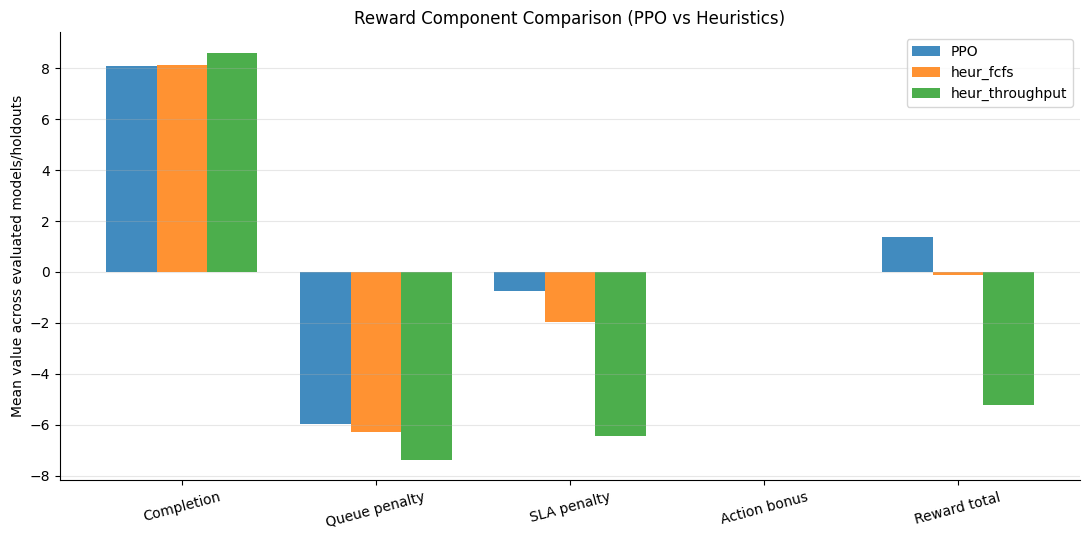

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sb3_contrib import MaskablePPO

PPO_COMPONENTS_EXPORT_PATH = OUTPUT_DIR / 'ppo_reward_components.csv'
PPO_COMPONENTS_LIVE_EXPORT_PATH = OUTPUT_DIR / 'live_progress' / 'ppo_reward_components_live.csv'
PPO_COMPONENTS_LIVE_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

METRICS_PATH = OUTPUT_DIR / 'ppo_metrics.csv'
TRAINED_MODELS_DIR = OUTPUT_DIR / 'trained_models'
COMPONENT_KEYS = [
    'comp_completion_mean',
    'comp_queue_penalty_mean',
    'comp_sla_penalty_mean',
    'comp_action_bonus_mean',
    'comp_reward_total_mean',
]

fixed_eval_seeds = globals().get('fixed_eval_seeds', [1042 + i for i in range(12)])
eval_arrival_rate = float(globals().get('eval_arrival_rate', 2.0))
eval_bonus_scale = float(globals().get('eval_bonus_scale', 0.0))

metrics_df = pd.read_csv(METRICS_PATH) if METRICS_PATH.exists() else pd.DataFrame()
path_to_holdout = {}
if len(metrics_df) > 0 and {'selected_checkpoint_path', 'held_out_municipality'}.issubset(metrics_df.columns):
    for _, row in metrics_df.iterrows():
        ck = str(row['selected_checkpoint_path'])
        hold = int(row['held_out_municipality'])
        path_to_holdout[str(Path(ck).name)] = hold

model_candidates = []
if TRAINED_MODELS_DIR.exists():
    model_candidates.extend(sorted(TRAINED_MODELS_DIR.glob('*.zip')))
if len(model_candidates) == 0 and len(metrics_df) > 0 and 'selected_checkpoint_path' in metrics_df.columns:
    for p in metrics_df['selected_checkpoint_path'].dropna().astype(str):
        pp = Path(p)
        if pp.exists() and pp.suffix.lower() == '.zip':
            model_candidates.append(pp)

if len(model_candidates) == 0:
    raise FileNotFoundError(
        f'No PPO .zip checkpoints found in {TRAINED_MODELS_DIR} and none resolvable from {METRICS_PATH}'
    )

def infer_holdout_from_name(path: Path):
    base = path.name
    if base in path_to_holdout:
        return int(path_to_holdout[base])
    m = re.search(r'holdout[_-]?M(\d+)', base, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    return None

rows = []
for model_path in model_candidates:
    held_out = infer_holdout_from_name(model_path)
    if held_out is None:
        print(f'Skipping model with unknown holdout mapping: {model_path.name}')
        continue

    print(f'Evaluating {model_path.name} on held-out M{held_out}...')
    model = MaskablePPO.load(str(model_path), device='auto')

    ppo_eval = evaluate_policy_detailed(
        model=model,
        municipality=held_out,
        arrival_rate=eval_arrival_rate,
        episode_seeds=fixed_eval_seeds,
        bonus_scale=eval_bonus_scale,
    )
    fcfs_eval = evaluate_heuristic_detailed(
        municipality=held_out,
        heuristic_mode='fcfs',
        arrival_rate=eval_arrival_rate,
        episode_seeds=fixed_eval_seeds,
        bonus_scale=eval_bonus_scale,
    )
    throughput_eval = evaluate_heuristic_detailed(
        municipality=held_out,
        heuristic_mode='throughput',
        arrival_rate=eval_arrival_rate,
        episode_seeds=fixed_eval_seeds,
        bonus_scale=eval_bonus_scale,
    )

    for source_name, eval_dict in [
        ('PPO', ppo_eval),
        ('heur_fcfs', fcfs_eval),
        ('heur_throughput', throughput_eval),
    ]:
        rec = {
            'model_file': model_path.name,
            'held_out_municipality': held_out,
            'source': source_name,
            'n_eval_episodes': int(eval_dict.get('n_episodes', len(fixed_eval_seeds))),
            'avg_reward': float(eval_dict.get('avg_reward', np.nan)),
            'reward_std': float(eval_dict.get('reward_std', np.nan)),
        }
        for key in COMPONENT_KEYS:
            rec[key] = float(eval_dict.get(key, np.nan))
        rows.append(rec)

component_df = pd.DataFrame(rows)
if len(component_df) == 0:
    raise RuntimeError('No component rows were generated. Check model filenames / holdout mapping.')

component_df.to_csv(PPO_COMPONENTS_EXPORT_PATH, index=False)
component_df.to_csv(PPO_COMPONENTS_LIVE_EXPORT_PATH, index=False)

print(f'Saved PPO component export: {PPO_COMPONENTS_EXPORT_PATH}')
print(f'Saved PPO live component export: {PPO_COMPONENTS_LIVE_EXPORT_PATH}')
display(component_df.head(20))

# Comparison plot: PPO vs heuristics per component, averaged across holdouts/models
plot_df = component_df.groupby('source', as_index=False)[COMPONENT_KEYS].mean()
pretty_labels = {
    'comp_completion_mean': 'Completion',
    'comp_queue_penalty_mean': 'Queue penalty',
    'comp_sla_penalty_mean': 'SLA penalty',
    'comp_action_bonus_mean': 'Action bonus',
    'comp_reward_total_mean': 'Reward total',
}

melt_df = plot_df.melt(id_vars='source', value_vars=COMPONENT_KEYS, var_name='component', value_name='value')
melt_df['component_label'] = melt_df['component'].map(pretty_labels).fillna(melt_df['component'])

pivot = melt_df.pivot(index='component_label', columns='source', values='value')
pivot = pivot.reindex([pretty_labels[k] for k in COMPONENT_KEYS])

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(pivot.index))
sources = [s for s in ['PPO', 'heur_fcfs', 'heur_throughput'] if s in pivot.columns]
width = 0.26 if len(sources) == 3 else 0.35

for i, src in enumerate(sources):
    vals = pd.to_numeric(pivot[src], errors='coerce').to_numpy(dtype=float)
    offset = (i - (len(sources)-1)/2) * width
    ax.bar(x + offset, vals, width=width, label=src, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15)
ax.set_ylabel('Mean value across evaluated models/holdouts')
ax.set_title('Reward Component Comparison (PPO vs Heuristics)')
ax.grid(axis='y', alpha=0.3)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()